Loaded summary rows: 160
Loaded baselines: 8 / 8


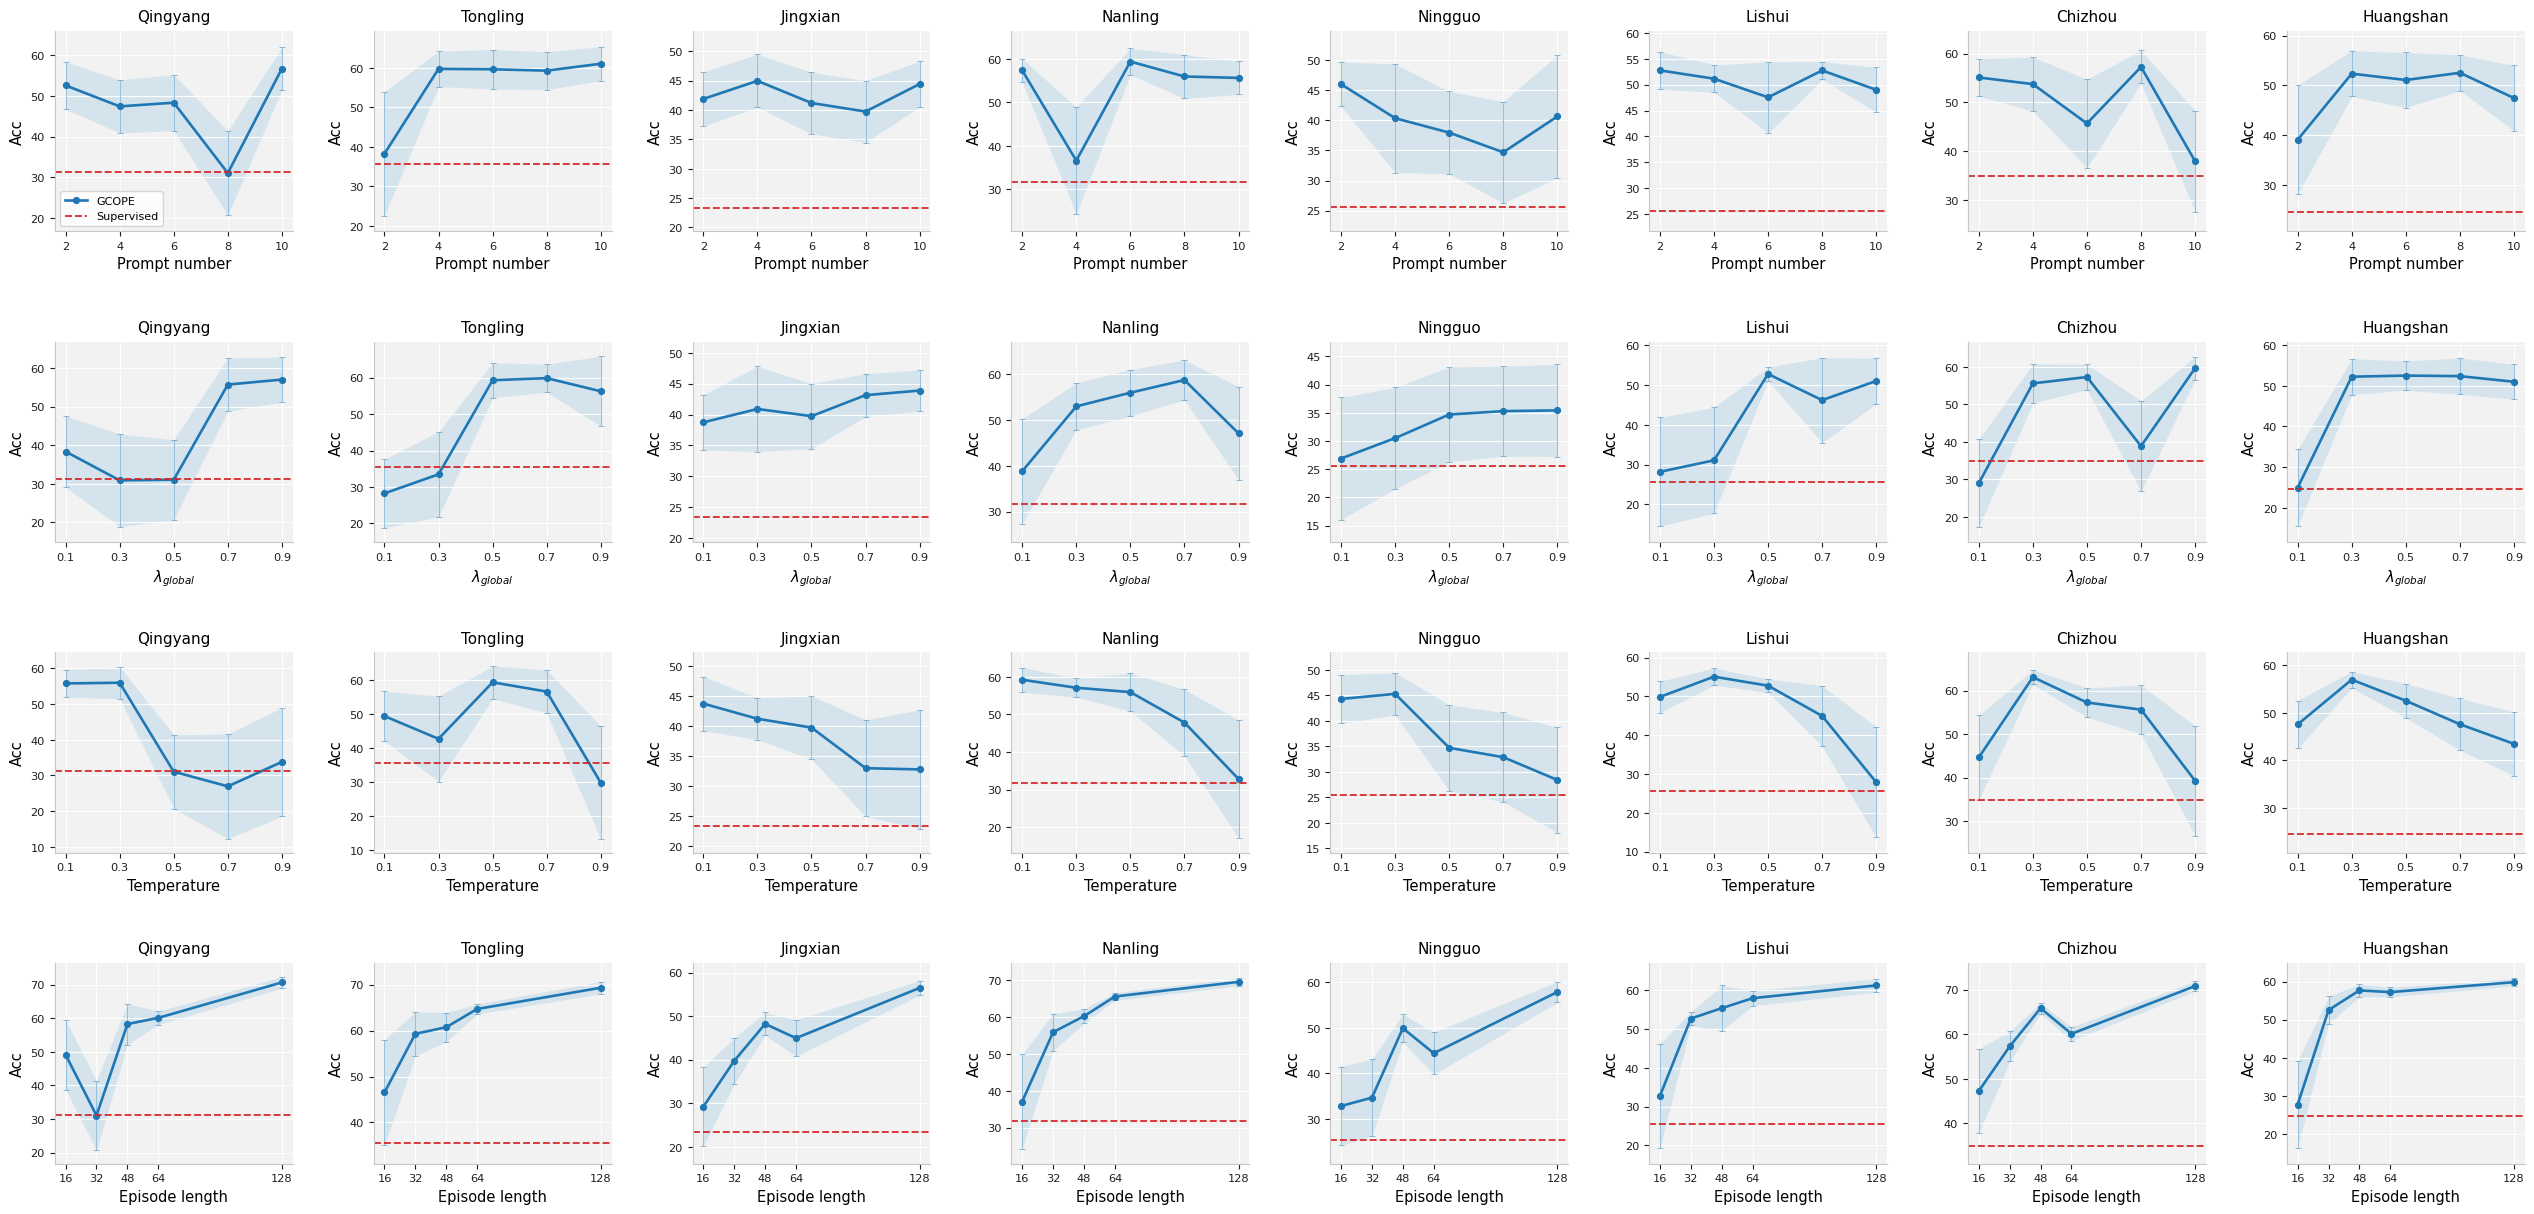

Saved JPG to: /home/ustc1958/lxy/graph/tone/complete_package0614/pc_dlcmnet_figures_hybrid/hyperparam_accuracy_4x8.jpg


In [9]:
import csv
from pathlib import Path

import matplotlib.pyplot as plt


# =========================
# 1. Configuration
# =========================

SUMMARY_CSV = Path(
    "/home/ustc1958/lxy/graph/tone/complete_package0614/output/0614/"
    "hyperparam_sensitivity_8targets_k4_full_20260703_4sweeps/summary.csv"
)

OUTPUT_JPG = Path(
    "/home/ustc1958/lxy/graph/tone/complete_package0614/"
    "pc_dlcmnet_figures_hybrid/hyperparam_accuracy_4x8.jpg"
)

BASELINE_TABLES = [
    Path(
        "/home/ustc1958/lxy/graph/tone/complete_package0614/output/0614/"
        "paper_ready_results/main_acc_table_global_support_s100.csv"
    ),
    Path(
        "/home/ustc1958/lxy/graph/tone/complete_package0614/output/0614/"
        "paper_ready_results/main_acc_4shot_add2_missing_baselines.csv"
    ),
]

AREA_ORDER = [
    "Qingyang", "Tongling", "Jingxian", "Nanling",
    "Ningguo", "Lishui", "Chizhou", "Huangshan"
]

SWEEPS = ["num_prompts", "lambda_global", "temperature", "episode_length"]

SWEEP_LABELS = {
    "num_prompts": "Prompt number",
    "lambda_global": r"$\lambda_{global}$",
    "temperature": "Temperature",
    "episode_length": "Episode length",
}

BASELINE_METHOD = "WavLM"

GCOPE_COLOR = "#1f77b4"
SHADE_COLOR = "#9ecae1"
BASELINE_COLOR = "#d62728"

# 仅用于可视化放大阴影，不改变原始数据
STD_VIS_SCALE = 2

DPI = 300


# =========================
# 2. Helper functions
# =========================

def as_float(value):
    return float(str(value).strip())


def clean_row(row):
    return {str(k).lstrip("\ufeff"): v for k, v in row.items()}


def method_matches(name, target):
    clean_name = name.lower().replace("~", "").replace(" ", "").replace("-", "")
    clean_target = target.lower().replace("~", "").replace(" ", "").replace("-", "")
    return clean_name == clean_target


def load_summary_rows(summary_csv):
    rows = []
    with summary_csv.open("r", encoding="utf-8-sig", newline="") as f:
        reader = csv.DictReader(f)
        for raw_row in reader:
            row = clean_row(raw_row)

            # skipped 表示结果已存在而跳过重跑，也应计入画图
            if row.get("returncode") == "0" and row.get("status") in {"done", "skipped"}:
                rows.append(row)

    if not rows:
        raise RuntimeError(f"No valid rows found in {summary_csv}")

    return rows


def group_by_sweep_area(rows):
    grouped = {}

    for row in rows:
        key = (row["sweep"], row["area"])
        grouped.setdefault(key, []).append(row)

    for key in grouped:
        grouped[key].sort(key=lambda r: as_float(r["value"]))

    return grouped


def load_baselines(baseline_tables, method=BASELINE_METHOD):
    baselines = {}

    for path in baseline_tables:
        if not path.exists():
            continue

        with path.open("r", encoding="utf-8-sig", newline="") as f:
            reader = csv.DictReader(f)

            for raw_row in reader:
                row = clean_row(raw_row)

                if not method_matches(row.get("Method", ""), method):
                    continue

                for area in AREA_ORDER:
                    value = row.get(area, "")
                    if value:
                        baselines[area] = as_float(value) * 100.0

    return baselines


# =========================
# 3. Load data
# =========================

rows = load_summary_rows(SUMMARY_CSV)
grouped = group_by_sweep_area(rows)
baselines = load_baselines(BASELINE_TABLES, BASELINE_METHOD)

print(f"Loaded summary rows: {len(rows)}")
print(f"Loaded baselines: {len(baselines)} / {len(AREA_ORDER)}")


# =========================
# 4. Plot
# =========================

fig, axes = plt.subplots(
    nrows=len(SWEEPS),
    ncols=len(AREA_ORDER),
    figsize=(26, 12.8),
    sharey=False,
)

fig.patch.set_facecolor("white")

for row_idx, sweep in enumerate(SWEEPS):
    for col_idx, area in enumerate(AREA_ORDER):
        ax = axes[row_idx][col_idx]

        data = grouped.get((sweep, area), [])

        x = [as_float(item["value"]) for item in data]
        y = [as_float(item["accuracy"]) * 100.0 for item in data]

        y_std = [
            as_float(item.get("accuracy_std", "0")) * 100.0 * STD_VIS_SCALE
            for item in data
        ]

        y_low = [max(0.0, mean - std) for mean, std in zip(y, y_std)]
        y_high = [min(100.0, mean + std) for mean, std in zip(y, y_std)]

        ax.set_facecolor("#f2f2f2")

        if x:
            ax.fill_between(
                x,
                y_low,
                y_high,
                color=SHADE_COLOR,
                alpha=0.34,
                linewidth=0,
            )

            ax.errorbar(
                x,
                y,
                yerr=y_std,
                fmt="none",
                ecolor=GCOPE_COLOR,
                elinewidth=0.75,
                capsize=2.2,
                capthick=0.75,
                alpha=0.45,
                zorder=2,
            )

            ax.plot(
                x,
                y,
                marker="o",
                linewidth=1.9,
                markersize=4.2,
                color=GCOPE_COLOR,
                label="GCOPE",
            )

        if area in baselines:
            ax.axhline(
                baselines[area],
                color=BASELINE_COLOR,
                linestyle="--",
                linewidth=1.35,
                alpha=0.95,
                label="Supervised",
            )

        y_candidates = y_low + y_high
        if area in baselines:
            y_candidates.append(baselines[area])

        if y_candidates:
            ymin = max(0.0, min(y_candidates) - 4.0)
            ymax = min(100.0, max(y_candidates) + 4.0)

            if ymax - ymin < 14.0:
                mid = (ymax + ymin) / 2.0
                ymin = max(0.0, mid - 7.0)
                ymax = min(100.0, mid + 7.0)

            ax.set_ylim(ymin, ymax)

        ax.set_xticks(x)

        ax.grid(True, axis="y", color="white", linewidth=0.8, alpha=0.95)
        ax.grid(True, axis="x", color="white", linewidth=0.8, alpha=0.95)

        ax.tick_params(axis="x", labelsize=8.2, colors="#1f1f1f")
        ax.tick_params(axis="y", labelsize=8.2, colors="#1f1f1f")

        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)

        ax.spines["left"].set_color("#c7c7c7")
        ax.spines["bottom"].set_color("#c7c7c7")

        ax.set_title(area, fontsize=11, pad=7)
        ax.set_ylabel("Acc", fontsize=10.5)
        ax.set_xlabel(SWEEP_LABELS[sweep], fontsize=10.5)

        if row_idx == 0 and col_idx == 0:
            handles, labels = ax.get_legend_handles_labels()
            if handles:
                ax.legend(
                    handles,
                    labels,
                    loc="best",
                    fontsize=8,
                    frameon=True,
                    framealpha=0.8,
                )


# fig.suptitle(
#     "Hyperparameter sensitivity across eight regions",
#     fontsize=15,
#     y=0.985,
# )

fig.subplots_adjust(
    left=0.045,
    right=0.995,
    top=0.94,
    bottom=0.055,
    wspace=0.34,
    hspace=0.55,
)

OUTPUT_JPG.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(OUTPUT_JPG, dpi=DPI, bbox_inches="tight", pil_kwargs={"quality": 95})
plt.show()
plt.close(fig)

print(f"Saved JPG to: {OUTPUT_JPG}")

Loaded summary rows: 160
Loaded baselines: 8 / 8
Saved JPG to: /home/ustc1958/lxy/graph/tone/complete_package0614/pc_dlcmnet_figures_hybrid/hyperparam_accuracy_4x8.jpg


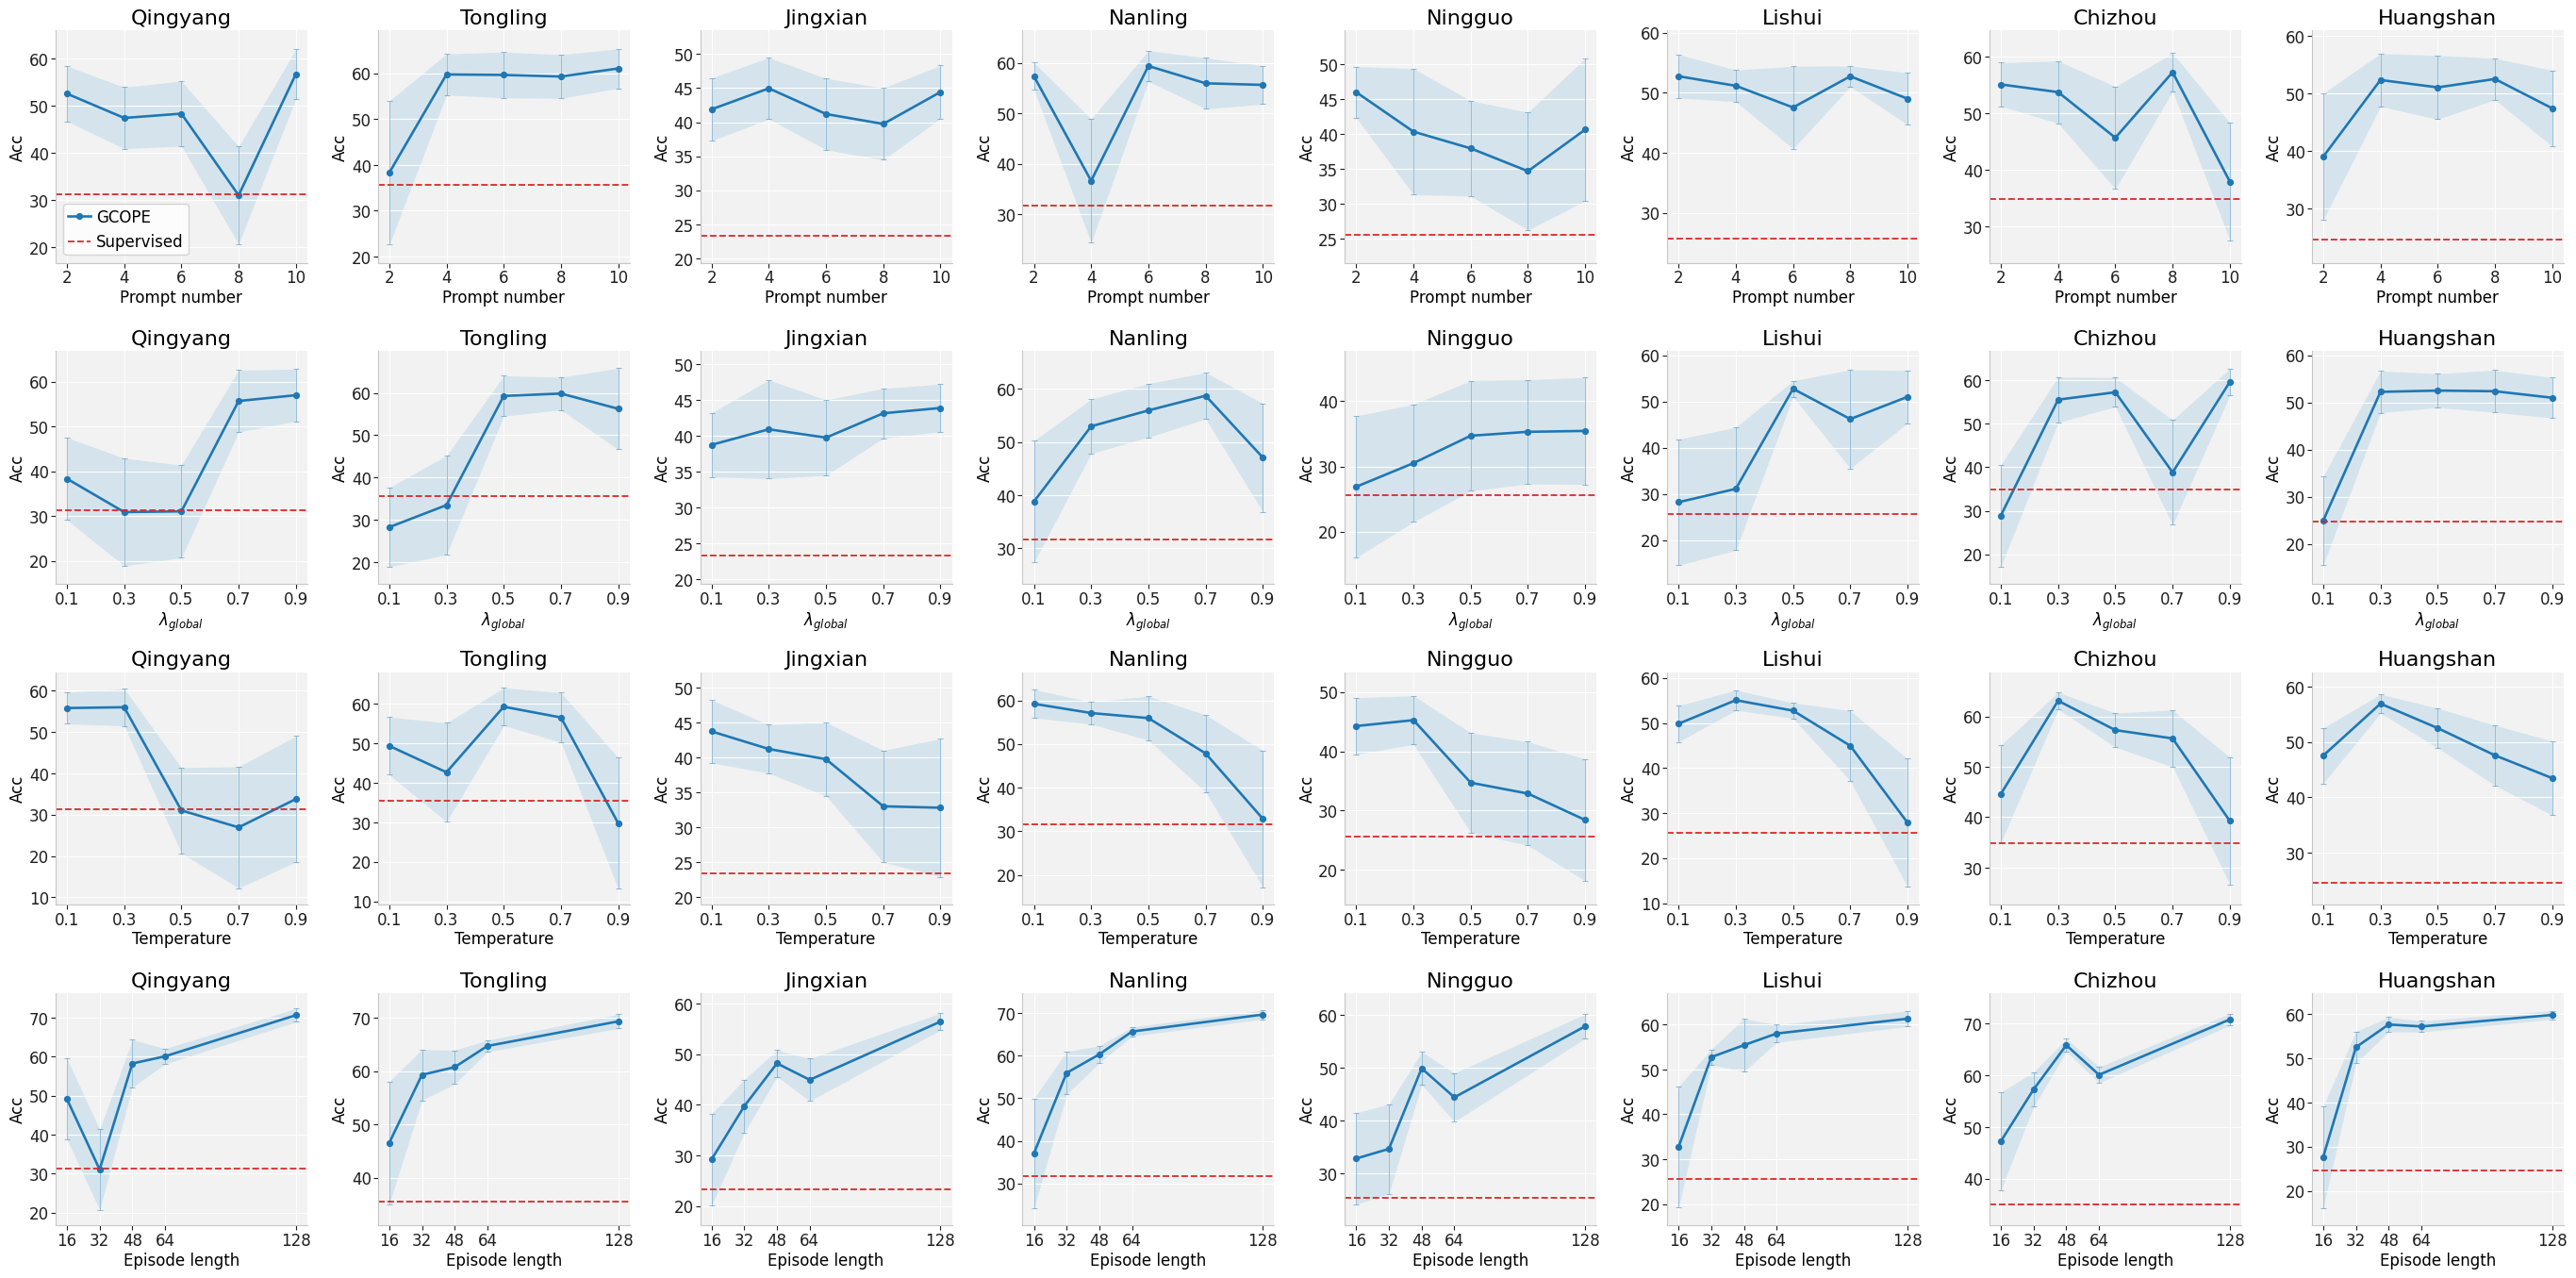

In [6]:
import csv
from pathlib import Path

import matplotlib.pyplot as plt
import logging
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

# =========================
# 1. Configuration
# =========================

SUMMARY_CSV = Path(
    "/home/ustc1958/lxy/graph/tone/complete_package0614/output/0614/"
    "hyperparam_sensitivity_8targets_k4_full_20260703_4sweeps/summary.csv"
)

OUTPUT_JPG = Path(
    "/home/ustc1958/lxy/graph/tone/complete_package0614/"
    "pc_dlcmnet_figures_hybrid/hyperparam_accuracy_4x8.jpg"
)

BASELINE_TABLES = [
    Path(
        "/home/ustc1958/lxy/graph/tone/complete_package0614/output/0614/"
        "paper_ready_results/main_acc_table_global_support_s100.csv"
    ),
    Path(
        "/home/ustc1958/lxy/graph/tone/complete_package0614/output/0614/"
        "paper_ready_results/main_acc_4shot_add2_missing_baselines.csv"
    ),
]

AREA_ORDER = [
    "Qingyang", "Tongling", "Jingxian", "Nanling",
    "Ningguo", "Lishui", "Chizhou", "Huangshan"
]

SWEEPS = ["num_prompts", "lambda_global", "temperature", "episode_length"]

SWEEP_LABELS = {
    "num_prompts": "Prompt number",
    "lambda_global": r"$\lambda_{global}$",
    "temperature": "Temperature",
    "episode_length": "Episode length",
}

BASELINE_METHOD = "WavLM"
# =========================
# 1.1 Figure size
# =========================

# 整张图的宽度，单位是 inch；数值越大，图越宽
FIG_WIDTH = 28.0

# 整张图的高度，单位是 inch；数值越大，图越高
FIG_HEIGHT = 14

# 图片分辨率，论文图一般用 300；如果要更清楚可以设为 600
DPI = 300

# 是否在运行脚本时显示图像窗口；服务器无图形界面时可设为 False
SHOW_FIG = True

# 是否保存图像到 OUTPUT_JPG
SAVE_FIG = True


# =========================
# 1.2 Font settings
# =========================

# 全局字体；服务器没有 Times New Roman 时会自动回退，可改成 "DejaVu Serif"
FONT_FAMILY = "Times New Roman"

# 全局默认字号；没有单独指定字号的文本会使用这个大小
GLOBAL_FONT_SIZE = 16

# 每个子图顶部区域名的字号，例如 Qingyang、Tongling
AREA_TITLE_FONT_SIZE = 16

# 横轴和纵轴标签字号，例如 Acc、Prompt number、Temperature
AXIS_LABEL_FONT_SIZE = 12

# 坐标轴刻度字号，例如 x 轴上的 1/2/4/8，y 轴上的准确率数值
TICK_LABEL_FONT_SIZE = 12

# 图例字号，例如 GCOPE、Supervised
LEGEND_FONT_SIZE = 12

# 子图标题与图像区域之间的距离；越大标题离图越远
AREA_TITLE_PAD = 5

# 坐标轴标签与坐标轴之间的距离；越大标签离坐标轴越远
AXIS_LABEL_PAD = 2

# 坐标轴刻度数字与坐标轴之间的距离；越大刻度数字离轴越远
TICK_PAD = 1.5


# =========================
# 1.3 Subplot spacing
# =========================

# 整张图左侧边距；数值越大，左边留白越多
SUBPLOT_LEFT = 0.045

# 整张图右侧边界；越接近 1，右边留白越少
SUBPLOT_RIGHT = 0.995

# 整张图上侧边界；越接近 1，上方留白越少
SUBPLOT_TOP = 0.965

# 整张图下侧边距；数值越大，下方留白越多
SUBPLOT_BOTTOM = 0.060

# 子图之间的横向间距；数值越大，每一列之间越宽
SUBPLOT_WSPACE = 0.28

# 子图之间的纵向间距；数值越大，每一行之间越宽
SUBPLOT_HSPACE = 0.38


# =========================
# 1.4 Style settings
# =========================

# 每个子图内部背景色
AX_FACE_COLOR = "#f2f2f2"

# 整张图的背景色
FIG_FACE_COLOR = "white"

# 主方法曲线颜色，这里对应 GCOPE 曲线
GCOPE_COLOR = "#1f77b4"

# 标准差阴影区域颜色
SHADE_COLOR = "#9ecae1"

# 监督基线水平线颜色
BASELINE_COLOR = "#d62728"

# 网格线颜色
GRID_COLOR = "white"

# 坐标轴边框颜色
SPINE_COLOR = "#c7c7c7"

# 坐标轴刻度文字颜色
TICK_COLOR = "#1f1f1f"

# GCOPE 主曲线线宽
GCOPE_LINE_WIDTH = 1.9

# GCOPE 曲线节点大小
GCOPE_MARKER_SIZE = 4.2

# 误差棒线宽
ERROR_LINE_WIDTH = 0.75

# 误差棒端帽长度
ERROR_CAP_SIZE = 2.2

# 误差棒端帽线宽
ERROR_CAP_THICK = 0.75

# 误差棒透明度；越小越淡
ERROR_ALPHA = 0.45

# 标准差阴影透明度；越小越淡，越大越明显
SHADE_ALPHA = 0.34

# 监督基线水平虚线线宽
BASELINE_LINE_WIDTH = 1.35

# 监督基线透明度
BASELINE_ALPHA = 0.95

# 监督基线线型；"--" 表示虚线，"-" 表示实线
BASELINE_LINESTYLE = "--"

# 网格线线宽
GRID_LINE_WIDTH = 0.8

# 网格线透明度
GRID_ALPHA = 0.95

# 坐标轴边框线宽
SPINE_LINE_WIDTH = 0.8


# =========================
# 1.5 Legend settings
# =========================

# 图例位置；"best" 表示自动选择最合适的位置
LEGEND_LOC = "best"

# 是否显示图例边框
LEGEND_FRAME_ON = True

# 图例背景透明度；越小越透明
LEGEND_FRAME_ALPHA = 0.8

# 图例内部文字和边框之间的距离
LEGEND_BORDER_PAD = 0.3

# 图例中线段示例的长度
LEGEND_HANDLE_LENGTH = 1.4

# 图例中线段示例和文字之间的距离
LEGEND_HANDLE_TEXT_PAD = 0.4


# =========================
# 1.6 Y-axis range settings
# =========================

# y 轴上下额外留白；数值越大，曲线离上下边界越远
Y_MARGIN = 4.0

# y 轴最小显示跨度；避免数值太接近时图像被过度放大
MIN_Y_SPAN = 14.0

# 标准差可视化放大倍数；只影响阴影和误差棒，不改变原始 accuracy 数据
STD_VIS_SCALE = 2.0


# =========================
# 1.7 Global rcParams
# =========================

# Matplotlib 全局绘图参数
plt.rcParams.update({
    # 设置全局字体
    "font.family": FONT_FAMILY,

    # 设置全局默认字号
    "font.size": GLOBAL_FONT_SIZE,

    # 设置子图标题字号
    "axes.titlesize": AREA_TITLE_FONT_SIZE,

    # 设置坐标轴标签字号
    "axes.labelsize": AXIS_LABEL_FONT_SIZE,

    # 设置 x 轴刻度字号
    "xtick.labelsize": TICK_LABEL_FONT_SIZE,

    # 设置 y 轴刻度字号
    "ytick.labelsize": TICK_LABEL_FONT_SIZE,

    # 设置图例字号
    "legend.fontsize": LEGEND_FONT_SIZE,

    # 设置坐标轴边框线宽
    "axes.linewidth": SPINE_LINE_WIDTH,

    # 保存 PDF 时保留可编辑字体，适合论文排版
    "pdf.fonttype": 42,

    # 保存 PS/EPS 时保留可编辑字体
    "ps.fonttype": 42,
})


# =========================
# 2. Helper functions
# =========================

def as_float(value):
    return float(str(value).strip())


def clean_row(row):
    return {str(k).lstrip("\ufeff"): v for k, v in row.items()}


def method_matches(name, target):
    clean_name = name.lower().replace("~", "").replace(" ", "").replace("-", "")
    clean_target = target.lower().replace("~", "").replace(" ", "").replace("-", "")
    return clean_name == clean_target


def load_summary_rows(summary_csv):
    rows = []

    with summary_csv.open("r", encoding="utf-8-sig", newline="") as f:
        reader = csv.DictReader(f)

        for raw_row in reader:
            row = clean_row(raw_row)

            # skipped 表示结果已存在而跳过重跑，也应计入画图
            if row.get("returncode") == "0" and row.get("status") in {"done", "skipped"}:
                rows.append(row)

    if not rows:
        raise RuntimeError(f"No valid rows found in {summary_csv}")

    return rows


def group_by_sweep_area(rows):
    grouped = {}

    for row in rows:
        key = (row["sweep"], row["area"])
        grouped.setdefault(key, []).append(row)

    for key in grouped:
        grouped[key].sort(key=lambda r: as_float(r["value"]))

    return grouped


def load_baselines(baseline_tables, method=BASELINE_METHOD):
    baselines = {}

    for path in baseline_tables:
        if not path.exists():
            continue

        with path.open("r", encoding="utf-8-sig", newline="") as f:
            reader = csv.DictReader(f)

            for raw_row in reader:
                row = clean_row(raw_row)

                if not method_matches(row.get("Method", ""), method):
                    continue

                for area in AREA_ORDER:
                    value = row.get(area, "")

                    if value:
                        baselines[area] = as_float(value) * 100.0

    return baselines


# =========================
# 3. Load data
# =========================

rows = load_summary_rows(SUMMARY_CSV)
grouped = group_by_sweep_area(rows)
baselines = load_baselines(BASELINE_TABLES, BASELINE_METHOD)

print(f"Loaded summary rows: {len(rows)}")
print(f"Loaded baselines: {len(baselines)} / {len(AREA_ORDER)}")


# =========================
# 4. Plot
# =========================

fig, axes = plt.subplots(
    nrows=len(SWEEPS),
    ncols=len(AREA_ORDER),
    figsize=(FIG_WIDTH, FIG_HEIGHT),
    sharey=False,
)

fig.patch.set_facecolor(FIG_FACE_COLOR)

for row_idx, sweep in enumerate(SWEEPS):
    for col_idx, area in enumerate(AREA_ORDER):
        ax = axes[row_idx][col_idx]

        data = grouped.get((sweep, area), [])

        x = [as_float(item["value"]) for item in data]
        y = [as_float(item["accuracy"]) * 100.0 for item in data]

        y_std = [
            as_float(item.get("accuracy_std", "0")) * 100.0 * STD_VIS_SCALE
            for item in data
        ]

        y_low = [max(0.0, mean - std) for mean, std in zip(y, y_std)]
        y_high = [min(100.0, mean + std) for mean, std in zip(y, y_std)]

        ax.set_facecolor(AX_FACE_COLOR)

        if x:
            ax.fill_between(
                x,
                y_low,
                y_high,
                color=SHADE_COLOR,
                alpha=SHADE_ALPHA,
                linewidth=0,
            )

            ax.errorbar(
                x,
                y,
                yerr=y_std,
                fmt="none",
                ecolor=GCOPE_COLOR,
                elinewidth=ERROR_LINE_WIDTH,
                capsize=ERROR_CAP_SIZE,
                capthick=ERROR_CAP_THICK,
                alpha=ERROR_ALPHA,
                zorder=2,
            )

            ax.plot(
                x,
                y,
                marker="o",
                linewidth=GCOPE_LINE_WIDTH,
                markersize=GCOPE_MARKER_SIZE,
                color=GCOPE_COLOR,
                label="GCOPE",
            )

        if area in baselines:
            ax.axhline(
                baselines[area],
                color=BASELINE_COLOR,
                linestyle=BASELINE_LINESTYLE,
                linewidth=BASELINE_LINE_WIDTH,
                alpha=BASELINE_ALPHA,
                label="Supervised",
            )

        y_candidates = y_low + y_high

        if area in baselines:
            y_candidates.append(baselines[area])

        if y_candidates:
            ymin = max(0.0, min(y_candidates) - Y_MARGIN)
            ymax = min(100.0, max(y_candidates) + Y_MARGIN)

            if ymax - ymin < MIN_Y_SPAN:
                mid = (ymax + ymin) / 2.0
                ymin = max(0.0, mid - MIN_Y_SPAN / 2.0)
                ymax = min(100.0, mid + MIN_Y_SPAN / 2.0)

            ax.set_ylim(ymin, ymax)

        ax.set_xticks(x)

        ax.grid(
            True,
            axis="y",
            color=GRID_COLOR,
            linewidth=GRID_LINE_WIDTH,
            alpha=GRID_ALPHA,
        )
        ax.grid(
            True,
            axis="x",
            color=GRID_COLOR,
            linewidth=GRID_LINE_WIDTH,
            alpha=GRID_ALPHA,
        )

        ax.tick_params(
            axis="x",
            labelsize=TICK_LABEL_FONT_SIZE,
            pad=TICK_PAD,
            colors=TICK_COLOR,
        )
        ax.tick_params(
            axis="y",
            labelsize=TICK_LABEL_FONT_SIZE,
            pad=TICK_PAD,
            colors=TICK_COLOR,
        )

        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)

        ax.spines["left"].set_color(SPINE_COLOR)
        ax.spines["bottom"].set_color(SPINE_COLOR)

        ax.spines["left"].set_linewidth(SPINE_LINE_WIDTH)
        ax.spines["bottom"].set_linewidth(SPINE_LINE_WIDTH)

        ax.set_title(
            area,
            fontsize=AREA_TITLE_FONT_SIZE,
            pad=AREA_TITLE_PAD,
        )

        ax.set_ylabel(
            "Acc",
            fontsize=AXIS_LABEL_FONT_SIZE,
            labelpad=AXIS_LABEL_PAD,
        )

        ax.set_xlabel(
            SWEEP_LABELS[sweep],
            fontsize=AXIS_LABEL_FONT_SIZE,
            labelpad=AXIS_LABEL_PAD,
        )

        if row_idx == 0 and col_idx == 0:
            handles, labels = ax.get_legend_handles_labels()

            if handles:
                ax.legend(
                    handles,
                    labels,
                    loc=LEGEND_LOC,
                    fontsize=LEGEND_FONT_SIZE,
                    frameon=LEGEND_FRAME_ON,
                    framealpha=LEGEND_FRAME_ALPHA,
                    borderpad=LEGEND_BORDER_PAD,
                    handlelength=LEGEND_HANDLE_LENGTH,
                    handletextpad=LEGEND_HANDLE_TEXT_PAD,
                )


fig.subplots_adjust(
    left=SUBPLOT_LEFT,
    right=SUBPLOT_RIGHT,
    top=SUBPLOT_TOP,
    bottom=SUBPLOT_BOTTOM,
    wspace=SUBPLOT_WSPACE,
    hspace=SUBPLOT_HSPACE,
)


# =========================
# 5. Save and show
# =========================

OUTPUT_JPG.parent.mkdir(parents=True, exist_ok=True)

if SAVE_FIG:
    fig.savefig(
        OUTPUT_JPG,
        dpi=DPI,
        bbox_inches="tight",
        pil_kwargs={"quality": 95},
    )
    print(f"Saved JPG to: {OUTPUT_JPG}")

if SHOW_FIG:
    plt.show()

plt.close(fig)

Loaded summary rows: 160
Loaded baselines: 8 / 8
Saved JPG to: /home/ustc1958/lxy/graph/tone/complete_package0614/pc_dlcmnet_figures_hybrid/hyperparam_accuracy_4x8.jpg


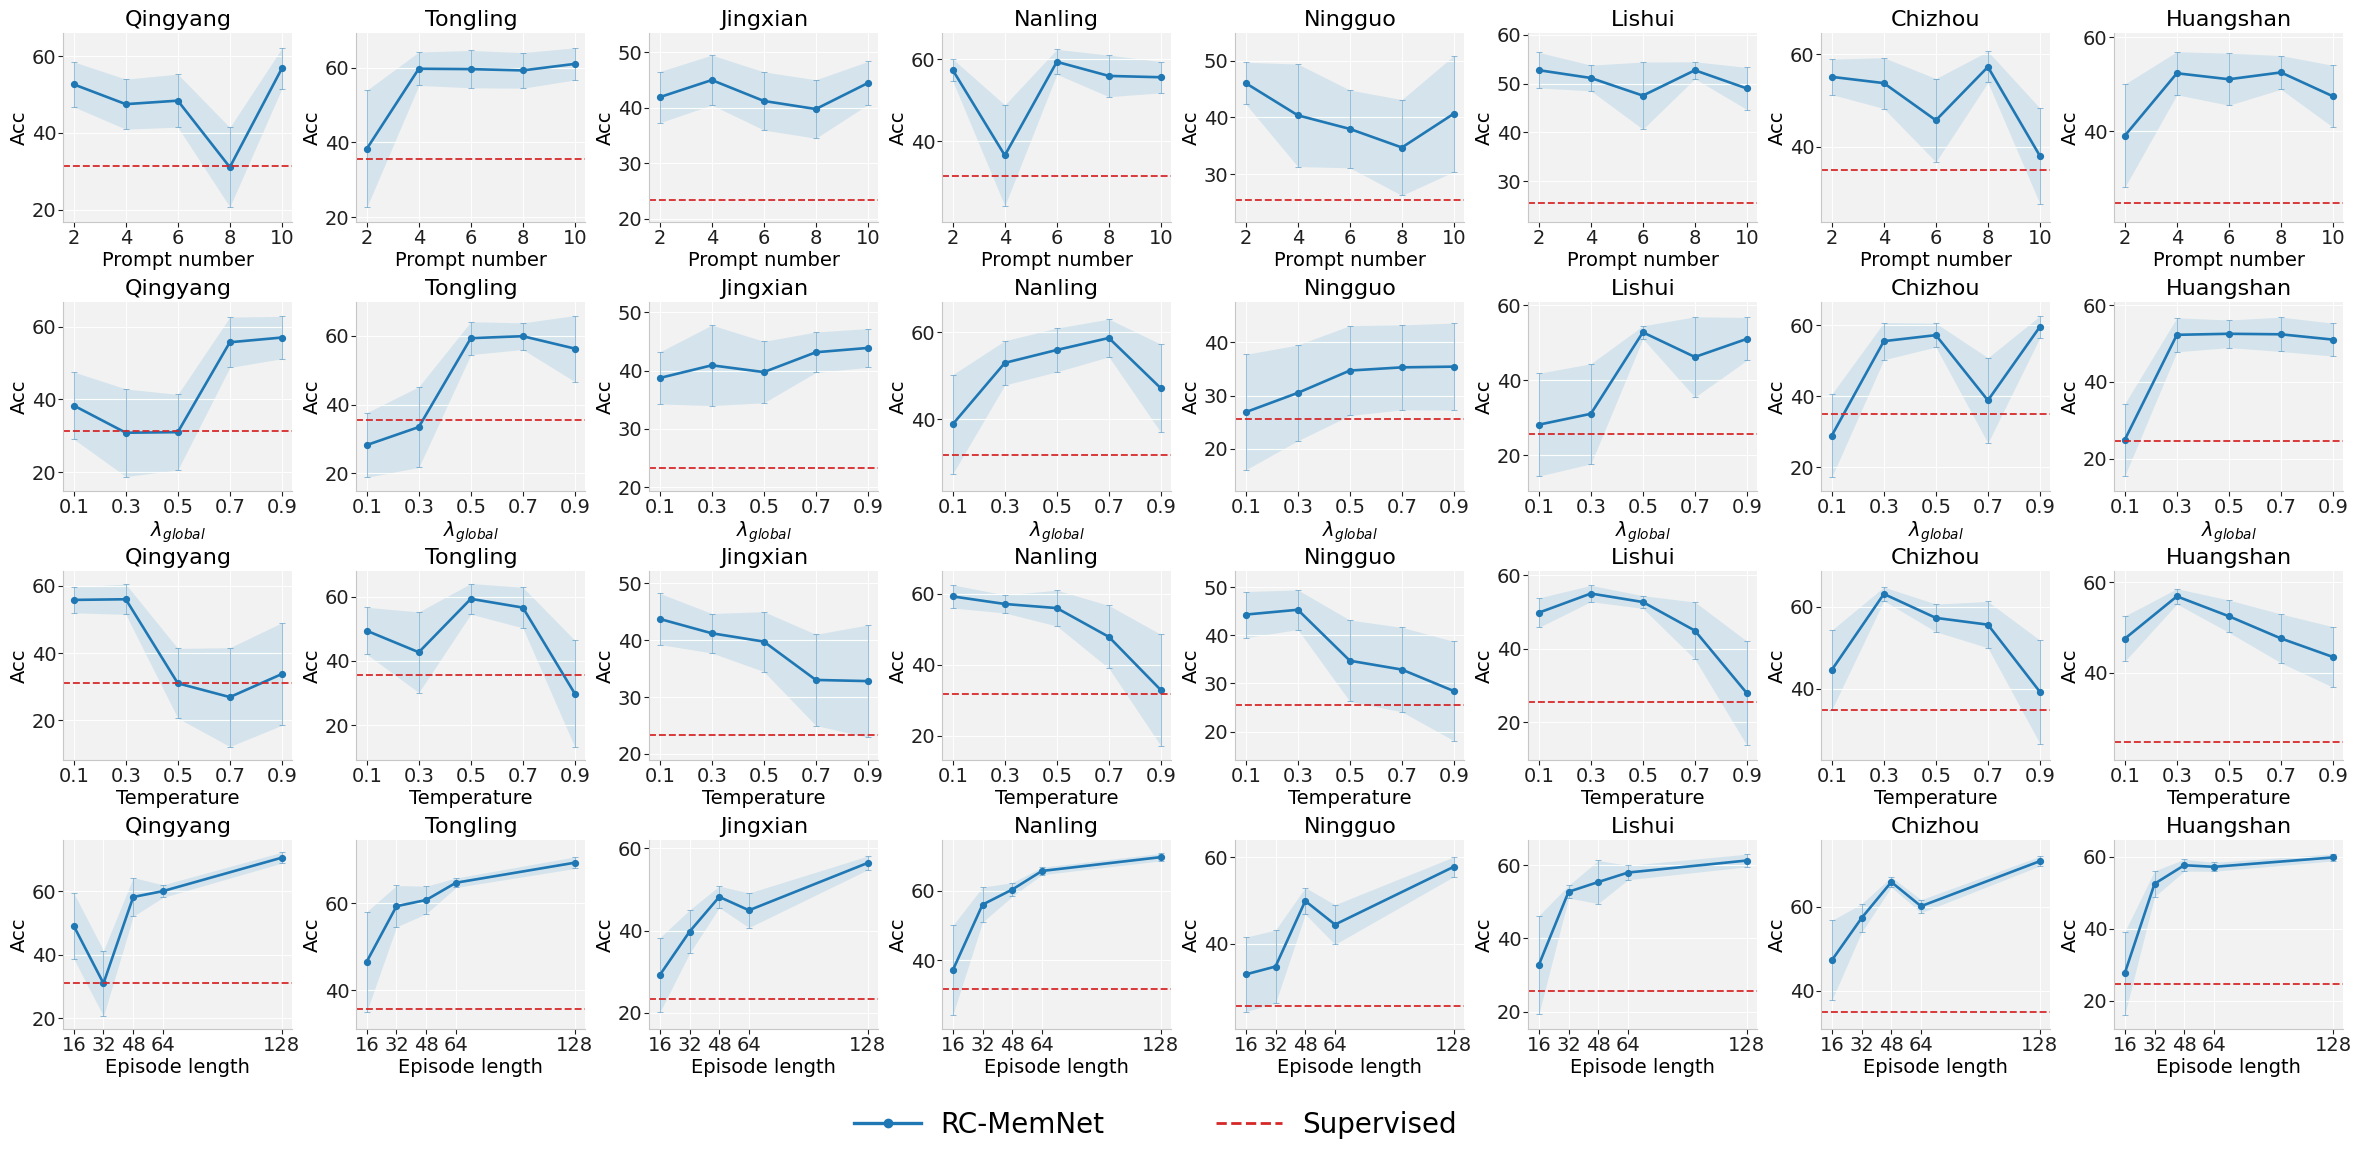

In [1]:
import csv
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import logging

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)


# =========================
# 1. Configuration
# =========================

SUMMARY_CSV = Path(
    "/home/ustc1958/lxy/graph/tone/complete_package0614/output/0614/"
    "hyperparam_sensitivity_8targets_k4_full_20260703_4sweeps/summary.csv"
)

OUTPUT_JPG = Path(
    "/home/ustc1958/lxy/graph/tone/complete_package0614/"
    "pc_dlcmnet_figures_hybrid/hyperparam_accuracy_4x8.jpg"
)

BASELINE_TABLES = [
    Path(
        "/home/ustc1958/lxy/graph/tone/complete_package0614/output/0614/"
        "paper_ready_results/main_acc_table_global_support_s100.csv"
    ),
    Path(
        "/home/ustc1958/lxy/graph/tone/complete_package0614/output/0614/"
        "paper_ready_results/main_acc_4shot_add2_missing_baselines.csv"
    ),
]

AREA_ORDER = [
    "Qingyang", "Tongling", "Jingxian", "Nanling",
    "Ningguo", "Lishui", "Chizhou", "Huangshan"
]

SWEEPS = ["num_prompts", "lambda_global", "temperature", "episode_length"]

SWEEP_LABELS = {
    "num_prompts": "Prompt number",
    "lambda_global": r"$\lambda_{global}$",
    "temperature": "Temperature",
    "episode_length": "Episode length",
}

BASELINE_METHOD = "WavLM"


# =========================
# 1.1 Figure size
# =========================

FIG_WIDTH = 24.0
FIG_HEIGHT = 12
DPI = 300

SHOW_FIG = True
SAVE_FIG = True


# =========================
# 1.2 Font settings
# =========================

FONT_FAMILY = "Times New Roman"

GLOBAL_FONT_SIZE = 16
AREA_TITLE_FONT_SIZE = 16
AXIS_LABEL_FONT_SIZE = 14
TICK_LABEL_FONT_SIZE = 14

# 底部图例字体大小
LEGEND_FONT_SIZE = 20

AREA_TITLE_PAD = 5
AXIS_LABEL_PAD = 2
TICK_PAD = 1.5


# =========================
# 1.3 Subplot spacing
# =========================

SUBPLOT_LEFT = 0.045
SUBPLOT_RIGHT = 0.995
SUBPLOT_TOP = 0.965

# 增大底部留白，给全局图例留空间
SUBPLOT_BOTTOM = 0.135

SUBPLOT_WSPACE = 0.28
SUBPLOT_HSPACE = 0.42


# =========================
# 1.4 Style settings
# =========================

AX_FACE_COLOR = "#f2f2f2"
FIG_FACE_COLOR = "white"

GCOPE_COLOR = "#1f77b4"
SHADE_COLOR = "#9ecae1"
BASELINE_COLOR = "#d62728"

GRID_COLOR = "white"
SPINE_COLOR = "#c7c7c7"
TICK_COLOR = "#1f1f1f"

GCOPE_LINE_WIDTH = 1.9
GCOPE_MARKER_SIZE = 4.2

ERROR_LINE_WIDTH = 0.75
ERROR_CAP_SIZE = 2.2
ERROR_CAP_THICK = 0.75
ERROR_ALPHA = 0.45

SHADE_ALPHA = 0.34

BASELINE_LINE_WIDTH = 1.35
BASELINE_ALPHA = 0.95
BASELINE_LINESTYLE = "--"

GRID_LINE_WIDTH = 0.8
GRID_ALPHA = 0.95

SPINE_LINE_WIDTH = 0.8


# =========================
# 1.5 Legend settings
# =========================

# 底部全局图例名称，在这里改即可
GLOBAL_LEGEND_CURVE_LABEL = "RC-MemNet"
GLOBAL_LEGEND_BASELINE_LABEL = "Supervised"

# 底部全局图例位置
GLOBAL_LEGEND_LOC = "lower center"
GLOBAL_LEGEND_BBOX = (0.5, 0.025)
GLOBAL_LEGEND_NCOL = 2

# 是否显示图例边框
LEGEND_FRAME_ON = False

# 图例背景透明度；frameon=False 时这个参数不会显示出来
LEGEND_FRAME_ALPHA = 0.8

# 图例内部文字和边框之间的距离
LEGEND_BORDER_PAD = 0.3

# 图例中线段示例的长度
LEGEND_HANDLE_LENGTH = 2.4

# 图例中线段示例和文字之间的距离
LEGEND_HANDLE_TEXT_PAD = 0.7

# 图例列间距
LEGEND_COLUMN_SPACING = 4.0


# =========================
# 1.6 Y-axis range settings
# =========================

Y_MARGIN = 4.0
MIN_Y_SPAN = 14.0

STD_VIS_SCALE = 2.0


# =========================
# 1.7 Global rcParams
# =========================

plt.rcParams.update({
    "font.family": FONT_FAMILY,
    "font.size": GLOBAL_FONT_SIZE,
    "axes.titlesize": AREA_TITLE_FONT_SIZE,
    "axes.labelsize": AXIS_LABEL_FONT_SIZE,
    "xtick.labelsize": TICK_LABEL_FONT_SIZE,
    "ytick.labelsize": TICK_LABEL_FONT_SIZE,
    "legend.fontsize": LEGEND_FONT_SIZE,
    "axes.linewidth": SPINE_LINE_WIDTH,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


# =========================
# 2. Helper functions
# =========================

def as_float(value):
    return float(str(value).strip())


def clean_row(row):
    return {str(k).lstrip("\ufeff"): v for k, v in row.items()}


def method_matches(name, target):
    clean_name = name.lower().replace("~", "").replace(" ", "").replace("-", "")
    clean_target = target.lower().replace("~", "").replace(" ", "").replace("-", "")
    return clean_name == clean_target


def load_summary_rows(summary_csv):
    rows = []

    with summary_csv.open("r", encoding="utf-8-sig", newline="") as f:
        reader = csv.DictReader(f)

        for raw_row in reader:
            row = clean_row(raw_row)

            # skipped 表示结果已存在而跳过重跑，也应计入画图
            if row.get("returncode") == "0" and row.get("status") in {"done", "skipped"}:
                rows.append(row)

    if not rows:
        raise RuntimeError(f"No valid rows found in {summary_csv}")

    return rows


def group_by_sweep_area(rows):
    grouped = {}

    for row in rows:
        key = (row["sweep"], row["area"])
        grouped.setdefault(key, []).append(row)

    for key in grouped:
        grouped[key].sort(key=lambda r: as_float(r["value"]))

    return grouped


def load_baselines(baseline_tables, method=BASELINE_METHOD):
    baselines = {}

    for path in baseline_tables:
        if not path.exists():
            continue

        with path.open("r", encoding="utf-8-sig", newline="") as f:
            reader = csv.DictReader(f)

            for raw_row in reader:
                row = clean_row(raw_row)

                if not method_matches(row.get("Method", ""), method):
                    continue

                for area in AREA_ORDER:
                    value = row.get(area, "")

                    if value:
                        baselines[area] = as_float(value) * 100.0

    return baselines


# =========================
# 3. Load data
# =========================

rows = load_summary_rows(SUMMARY_CSV)
grouped = group_by_sweep_area(rows)
baselines = load_baselines(BASELINE_TABLES, BASELINE_METHOD)

print(f"Loaded summary rows: {len(rows)}")
print(f"Loaded baselines: {len(baselines)} / {len(AREA_ORDER)}")


# =========================
# 4. Plot
# =========================

fig, axes = plt.subplots(
    nrows=len(SWEEPS),
    ncols=len(AREA_ORDER),
    figsize=(FIG_WIDTH, FIG_HEIGHT),
    sharey=False,
)

fig.patch.set_facecolor(FIG_FACE_COLOR)

for row_idx, sweep in enumerate(SWEEPS):
    for col_idx, area in enumerate(AREA_ORDER):
        ax = axes[row_idx][col_idx]

        data = grouped.get((sweep, area), [])

        x = [as_float(item["value"]) for item in data]
        y = [as_float(item["accuracy"]) * 100.0 for item in data]

        y_std = [
            as_float(item.get("accuracy_std", "0")) * 100.0 * STD_VIS_SCALE
            for item in data
        ]

        y_low = [max(0.0, mean - std) for mean, std in zip(y, y_std)]
        y_high = [min(100.0, mean + std) for mean, std in zip(y, y_std)]

        ax.set_facecolor(AX_FACE_COLOR)

        if x:
            ax.fill_between(
                x,
                y_low,
                y_high,
                color=SHADE_COLOR,
                alpha=SHADE_ALPHA,
                linewidth=0,
            )

            ax.errorbar(
                x,
                y,
                yerr=y_std,
                fmt="none",
                ecolor=GCOPE_COLOR,
                elinewidth=ERROR_LINE_WIDTH,
                capsize=ERROR_CAP_SIZE,
                capthick=ERROR_CAP_THICK,
                alpha=ERROR_ALPHA,
                zorder=2,
            )

            ax.plot(
                x,
                y,
                marker="o",
                linewidth=GCOPE_LINE_WIDTH,
                markersize=GCOPE_MARKER_SIZE,
                color=GCOPE_COLOR,
                label=GLOBAL_LEGEND_CURVE_LABEL,
            )

        if area in baselines:
            ax.axhline(
                baselines[area],
                color=BASELINE_COLOR,
                linestyle=BASELINE_LINESTYLE,
                linewidth=BASELINE_LINE_WIDTH,
                alpha=BASELINE_ALPHA,
                label=GLOBAL_LEGEND_BASELINE_LABEL,
            )

        y_candidates = y_low + y_high

        if area in baselines:
            y_candidates.append(baselines[area])

        if y_candidates:
            ymin = max(0.0, min(y_candidates) - Y_MARGIN)
            ymax = min(100.0, max(y_candidates) + Y_MARGIN)

            if ymax - ymin < MIN_Y_SPAN:
                mid = (ymax + ymin) / 2.0
                ymin = max(0.0, mid - MIN_Y_SPAN / 2.0)
                ymax = min(100.0, mid + MIN_Y_SPAN / 2.0)

            ax.set_ylim(ymin, ymax)

        ax.set_xticks(x)

        ax.grid(
            True,
            axis="y",
            color=GRID_COLOR,
            linewidth=GRID_LINE_WIDTH,
            alpha=GRID_ALPHA,
        )
        ax.grid(
            True,
            axis="x",
            color=GRID_COLOR,
            linewidth=GRID_LINE_WIDTH,
            alpha=GRID_ALPHA,
        )

        ax.tick_params(
            axis="x",
            labelsize=TICK_LABEL_FONT_SIZE,
            pad=TICK_PAD,
            colors=TICK_COLOR,
        )
        ax.tick_params(
            axis="y",
            labelsize=TICK_LABEL_FONT_SIZE,
            pad=TICK_PAD,
            colors=TICK_COLOR,
        )

        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)

        ax.spines["left"].set_color(SPINE_COLOR)
        ax.spines["bottom"].set_color(SPINE_COLOR)

        ax.spines["left"].set_linewidth(SPINE_LINE_WIDTH)
        ax.spines["bottom"].set_linewidth(SPINE_LINE_WIDTH)

        ax.set_title(
            area,
            fontsize=AREA_TITLE_FONT_SIZE,
            pad=AREA_TITLE_PAD,
        )

        ax.set_ylabel(
            "Acc",
            fontsize=AXIS_LABEL_FONT_SIZE,
            labelpad=AXIS_LABEL_PAD,
        )

        ax.set_xlabel(
            SWEEP_LABELS[sweep],
            fontsize=AXIS_LABEL_FONT_SIZE,
            labelpad=AXIS_LABEL_PAD,
        )


# =========================
# 5. Global legend
# =========================

legend_handles = [
    Line2D(
        [0], [0],
        color=GCOPE_COLOR,
        marker="o",
        linewidth=2.4,
        markersize=6.0,
        label=GLOBAL_LEGEND_CURVE_LABEL,
    ),
    Line2D(
        [0], [0],
        color=BASELINE_COLOR,
        linestyle=BASELINE_LINESTYLE,
        linewidth=2.0,
        label=GLOBAL_LEGEND_BASELINE_LABEL,
    ),
]

fig.legend(
    handles=legend_handles,
    loc=GLOBAL_LEGEND_LOC,
    bbox_to_anchor=GLOBAL_LEGEND_BBOX,
    ncol=GLOBAL_LEGEND_NCOL,
    fontsize=LEGEND_FONT_SIZE,
    frameon=LEGEND_FRAME_ON,
    framealpha=LEGEND_FRAME_ALPHA,
    borderpad=LEGEND_BORDER_PAD,
    handlelength=LEGEND_HANDLE_LENGTH,
    handletextpad=LEGEND_HANDLE_TEXT_PAD,
    columnspacing=LEGEND_COLUMN_SPACING,
)


fig.subplots_adjust(
    left=SUBPLOT_LEFT,
    right=SUBPLOT_RIGHT,
    top=SUBPLOT_TOP,
    bottom=SUBPLOT_BOTTOM,
    wspace=SUBPLOT_WSPACE,
    hspace=SUBPLOT_HSPACE,
)


# =========================
# 6. Save and show
# =========================

OUTPUT_JPG.parent.mkdir(parents=True, exist_ok=True)

if SAVE_FIG:
    fig.savefig(
        OUTPUT_JPG,
        dpi=DPI,
        bbox_inches="tight",
        pil_kwargs={"quality": 95},
    )
    print(f"Saved JPG to: {OUTPUT_JPG}")

if SHOW_FIG:
    plt.show()

plt.close(fig)

图的解释说明
这张图展示了模型在八个目标地区上的超参数敏感性。整张图为 4×8 子图布局，四行分别对应四类超参数：num_prompts、lambda_global、temperature 和 episode_length；八列分别对应八个目标地区。每个子图中，横轴表示当前超参数的取值，纵轴表示该地区上的分类准确率 Acc。
蓝色折线表示我们的方法在不同超参数设置下的性能变化。折线越高，说明该超参数取值下模型在对应地区的分类效果越好。通过观察蓝色折线的走势，可以判断模型对某个超参数是否敏感，以及较优取值大致落在哪个范围。
淡蓝色阴影表示性能波动范围，对应 accuracy_std，这里为了增强可视化效果做了放大显示。它反映的是同一超参数设置下多次评估划分带来的性能波动。阴影越宽，说明该设置下结果稳定性相对较弱；阴影较窄，则说明结果更稳定。
红色虚线表示 WavLM supervised baseline，即不使用本文方法中的 prompt routing / memory / adaptation 机制，只使用 WavLM 表示进行监督分类得到的基线性能。由于该 baseline 不依赖这些超参数，所以在每个子图中表现为一条水平线。
这张图主要想说明：我们的方法在大多数地区和多数超参数设置下都高于 WavLM supervised baseline，说明所提出的机制相较单纯使用预训练声学表示具有稳定增益。同时，不同地区对超参数的敏感程度不同，反映出跨地区语音差异会影响最优配置；但整体趋势没有出现剧烈失稳，说明模型对这些关键超参数具有一定鲁棒性。

Loaded summary rows: 160
Loaded baselines: 8 / 8
Saved JPG to: /home/ustc1958/lxy/graph/tone/complete_package0614/pc_dlcmnet_figures_hybrid/hyperparam_accuracy_4x8.jpg


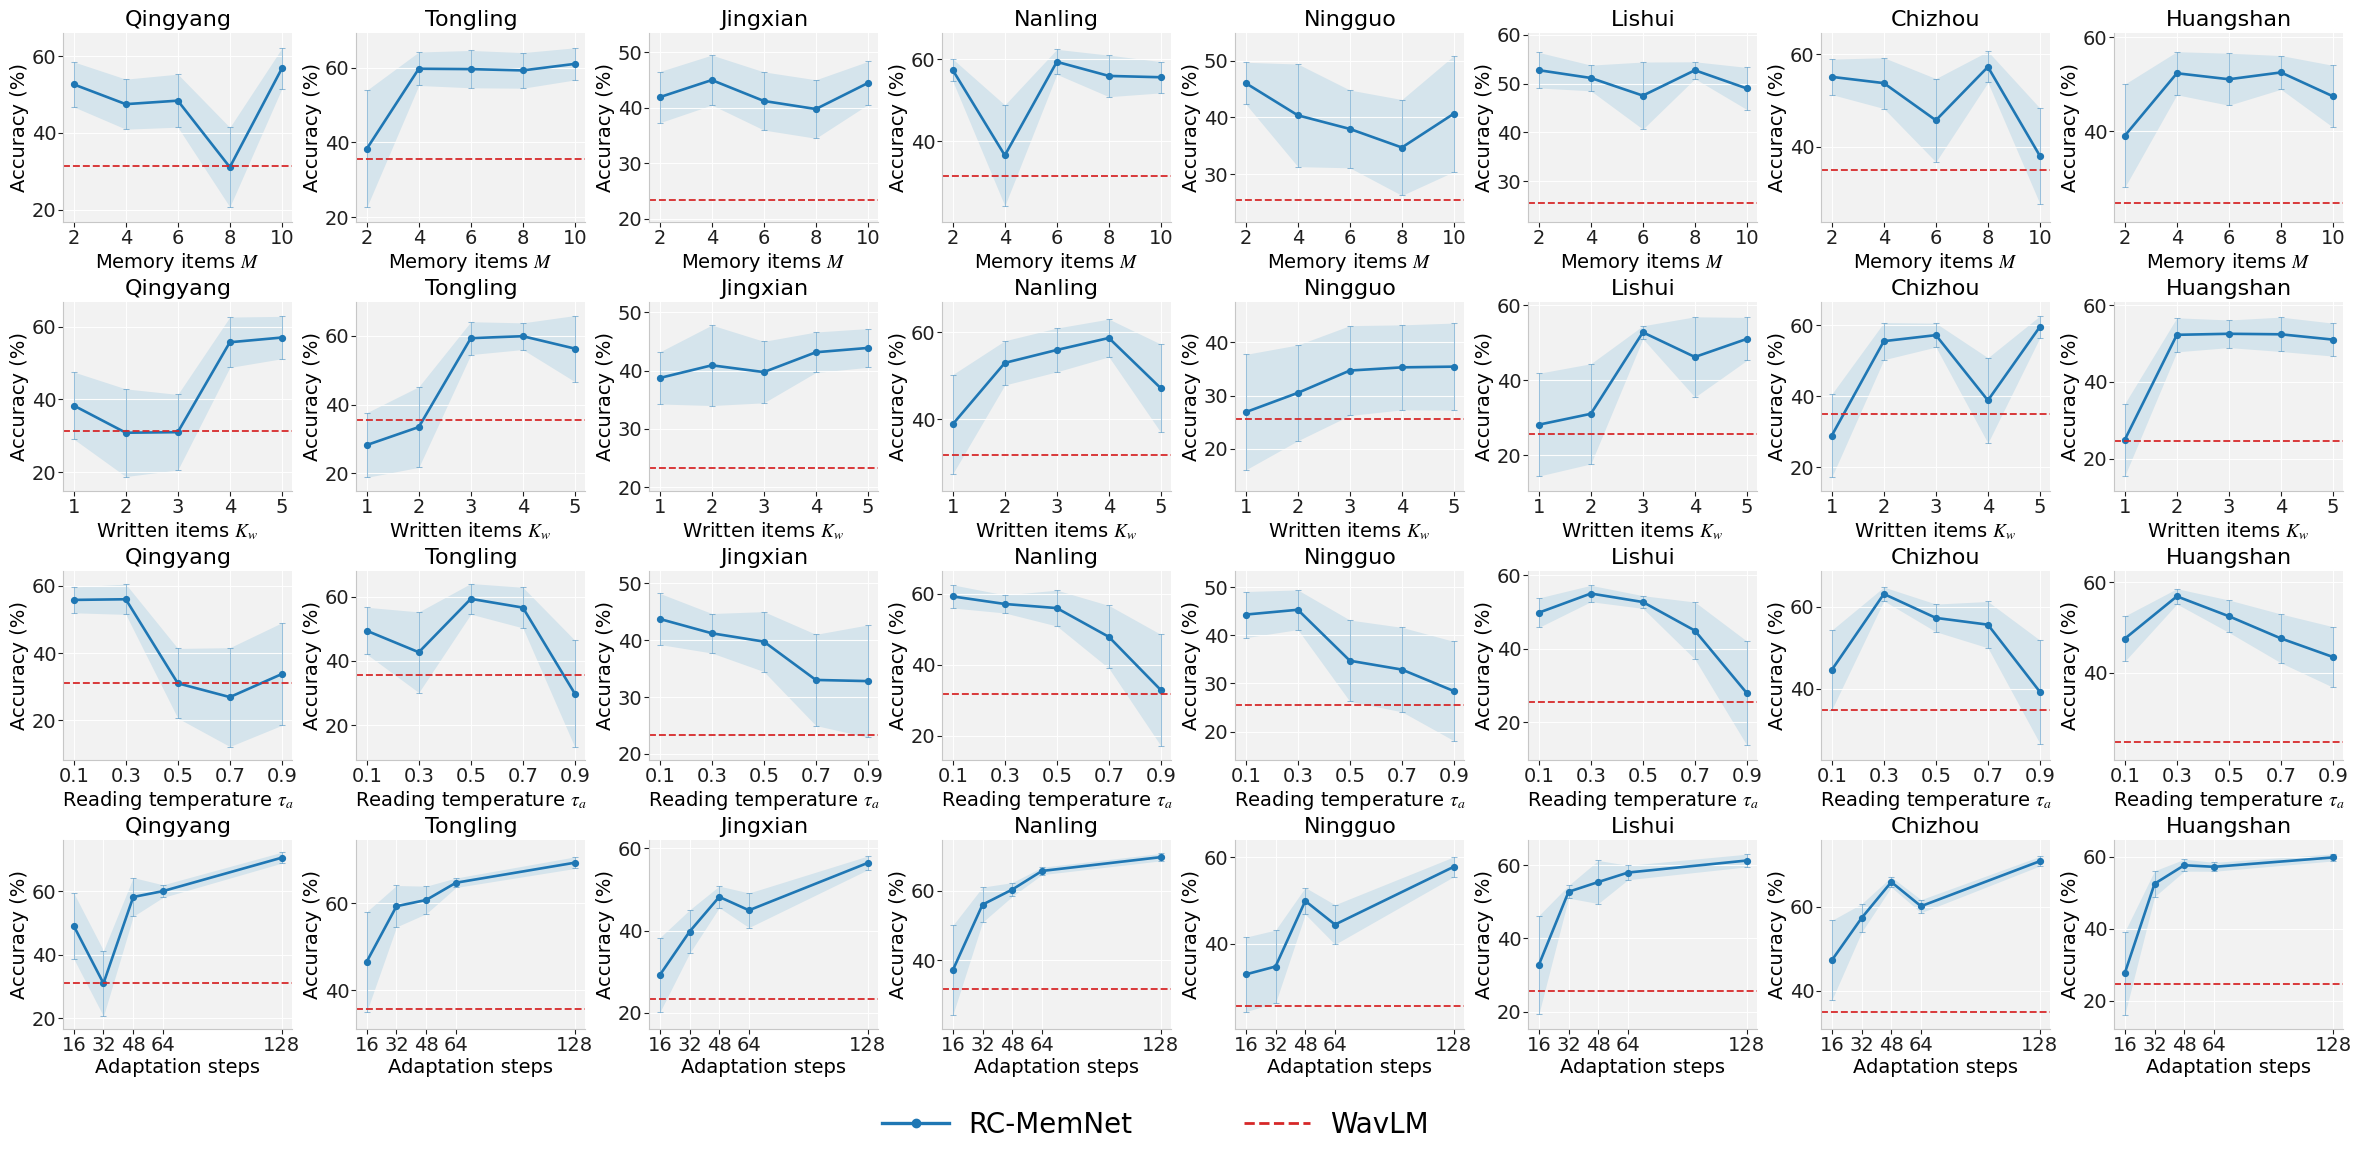

In [ ]:
import csv
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import logging

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)


# =========================
# 1. Configuration
# =========================

SUMMARY_CSV = Path(
    "/home/ustc1958/lxy/graph/tone/complete_package0614/output/0614/"
    "hyperparam_sensitivity_8targets_k4_full_20260703_4sweeps/summary.csv"
)

OUTPUT_JPG = Path(
    "/home/ustc1958/lxy/graph/tone/complete_package0614/"
    "pc_dlcmnet_figures_hybrid/hyperparam_accuracy_4x8.jpg"
)

BASELINE_TABLES = [
    Path(
        "/home/ustc1958/lxy/graph/tone/complete_package0614/output/0614/"
        "paper_ready_results/main_acc_table_global_support_s100.csv"
    ),
    Path(
        "/home/ustc1958/lxy/graph/tone/complete_package0614/output/0614/"
        "paper_ready_results/main_acc_4shot_add2_missing_baselines.csv"
    ),
]

AREA_ORDER = [
    "Qingyang", "Tongling", "Jingxian", "Nanling",
    "Ningguo", "Lishui", "Chizhou", "Huangshan"
]

# 保留原始 sweep 键，不改数据来源
SWEEPS = ["num_prompts", "lambda_global", "temperature", "episode_length"]

# =========================
# 1.0 统一为论文最终方法部分的四项消融名称
# =========================

SWEEP_LABELS = {
    "num_prompts": r"Memory items $M$",
    "lambda_global": r"Written items $K_w$",
    "temperature": r"Reading temperature $\tau_a$",
    "episode_length": "Training iteration",
}

# 只改 x 轴“显示标签”，不改曲线实际 x 坐标
# None: 保持原始 x 数值显示
# "auto_index": 按 1,2,...,N 自动显示
X_TICK_LABELS_BY_ORDER = {
    "num_prompts": None,
    "lambda_global": "auto_index",
    "temperature": None,
    "episode_length": None,
}

BASELINE_METHOD = "WavLM"


# =========================
# 1.1 Figure size
# =========================

FIG_WIDTH = 24.0
FIG_HEIGHT = 12
DPI = 300

SHOW_FIG = True
SAVE_FIG = True


# =========================
# 1.2 Font settings
# =========================

FONT_FAMILY = "Times New Roman"

GLOBAL_FONT_SIZE = 16
AREA_TITLE_FONT_SIZE = 16
AXIS_LABEL_FONT_SIZE = 14
TICK_LABEL_FONT_SIZE = 14

LEGEND_FONT_SIZE = 20

AREA_TITLE_PAD = 5
AXIS_LABEL_PAD = 2
TICK_PAD = 1.5


# =========================
# 1.3 Subplot spacing
# =========================

SUBPLOT_LEFT = 0.045
SUBPLOT_RIGHT = 0.995
SUBPLOT_TOP = 0.965
SUBPLOT_BOTTOM = 0.135

SUBPLOT_WSPACE = 0.28
SUBPLOT_HSPACE = 0.42


# =========================
# 1.4 Style settings
# =========================

AX_FACE_COLOR = "#f2f2f2"
FIG_FACE_COLOR = "white"

GCOPE_COLOR = "#1f77b4"
SHADE_COLOR = "#9ecae1"
BASELINE_COLOR = "#d62728"

GRID_COLOR = "white"
SPINE_COLOR = "#c7c7c7"
TICK_COLOR = "#1f1f1f"

GCOPE_LINE_WIDTH = 1.9
GCOPE_MARKER_SIZE = 4.2

ERROR_LINE_WIDTH = 0.75
ERROR_CAP_SIZE = 2.2
ERROR_CAP_THICK = 0.75
ERROR_ALPHA = 0.45

SHADE_ALPHA = 0.34

BASELINE_LINE_WIDTH = 1.35
BASELINE_ALPHA = 0.95
BASELINE_LINESTYLE = "--"

GRID_LINE_WIDTH = 0.8
GRID_ALPHA = 0.95

SPINE_LINE_WIDTH = 0.8


# =========================
# 1.5 Legend settings
# =========================

GLOBAL_LEGEND_CURVE_LABEL = "RC-MemNet"
GLOBAL_LEGEND_BASELINE_LABEL = "WavLM"

GLOBAL_LEGEND_LOC = "lower center"
GLOBAL_LEGEND_BBOX = (0.5, 0.025)
GLOBAL_LEGEND_NCOL = 2

LEGEND_FRAME_ON = False
LEGEND_FRAME_ALPHA = 0.8
LEGEND_BORDER_PAD = 0.3
LEGEND_HANDLE_LENGTH = 2.4
LEGEND_HANDLE_TEXT_PAD = 0.7
LEGEND_COLUMN_SPACING = 4.0


# =========================
# 1.6 Y-axis range settings
# =========================

Y_MARGIN = 4.0
MIN_Y_SPAN = 14.0

# 按你的要求，阴影不动
STD_VIS_SCALE = 2.0


# =========================
# 1.7 Global rcParams
# =========================

plt.rcParams.update({
    "font.family": FONT_FAMILY,
    "font.size": GLOBAL_FONT_SIZE,
    "axes.titlesize": AREA_TITLE_FONT_SIZE,
    "axes.labelsize": AXIS_LABEL_FONT_SIZE,
    "xtick.labelsize": TICK_LABEL_FONT_SIZE,
    "ytick.labelsize": TICK_LABEL_FONT_SIZE,
    "legend.fontsize": LEGEND_FONT_SIZE,
    "axes.linewidth": SPINE_LINE_WIDTH,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


# =========================
# 2. Helper functions
# =========================

def as_float(value):
    return float(str(value).strip())


def clean_row(row):
    return {str(k).lstrip("\ufeff"): v for k, v in row.items()}


def method_matches(name, target):
    clean_name = name.lower().replace("~", "").replace(" ", "").replace("-", "")
    clean_target = target.lower().replace("~", "").replace(" ", "").replace("-", "")
    return clean_name == clean_target


def load_summary_rows(summary_csv):
    rows = []

    with summary_csv.open("r", encoding="utf-8-sig", newline="") as f:
        reader = csv.DictReader(f)

        for raw_row in reader:
            row = clean_row(raw_row)

            if row.get("returncode") == "0" and row.get("status") in {"done", "skipped"}:
                rows.append(row)

    if not rows:
        raise RuntimeError(f"No valid rows found in {summary_csv}")

    return rows


def group_by_sweep_area(rows):
    grouped = {}

    for row in rows:
        key = (row["sweep"], row["area"])
        grouped.setdefault(key, []).append(row)

    for key in grouped:
        grouped[key].sort(key=lambda r: as_float(r["value"]))

    return grouped


def load_baselines(baseline_tables, method=BASELINE_METHOD):
    baselines = {}

    for path in baseline_tables:
        if not path.exists():
            continue

        with path.open("r", encoding="utf-8-sig", newline="") as f:
            reader = csv.DictReader(f)

            for raw_row in reader:
                row = clean_row(raw_row)

                if not method_matches(row.get("Method", ""), method):
                    continue

                for area in AREA_ORDER:
                    value = row.get(area, "")

                    if value:
                        baselines[area] = as_float(value) * 100.0

    return baselines


# =========================
# 3. Load data
# =========================

rows = load_summary_rows(SUMMARY_CSV)
grouped = group_by_sweep_area(rows)
baselines = load_baselines(BASELINE_TABLES, BASELINE_METHOD)

print(f"Loaded summary rows: {len(rows)}")
print(f"Loaded baselines: {len(baselines)} / {len(AREA_ORDER)}")


# =========================
# 4. Plot
# =========================

fig, axes = plt.subplots(
    nrows=len(SWEEPS),
    ncols=len(AREA_ORDER),
    figsize=(FIG_WIDTH, FIG_HEIGHT),
    sharey=False,
)

fig.patch.set_facecolor(FIG_FACE_COLOR)

for row_idx, sweep in enumerate(SWEEPS):
    for col_idx, area in enumerate(AREA_ORDER):
        ax = axes[row_idx][col_idx]

        data = grouped.get((sweep, area), [])

        x = [as_float(item["value"]) for item in data]
        y = [as_float(item["accuracy"]) * 100.0 for item in data]

        y_std = [
            as_float(item.get("accuracy_std", "0")) * 100.0 * STD_VIS_SCALE
            for item in data
        ]

        y_low = [max(0.0, mean - std) for mean, std in zip(y, y_std)]
        y_high = [min(100.0, mean + std) for mean, std in zip(y, y_std)]

        ax.set_facecolor(AX_FACE_COLOR)

        if x:
            ax.fill_between(
                x,
                y_low,
                y_high,
                color=SHADE_COLOR,
                alpha=SHADE_ALPHA,
                linewidth=0,
            )

            ax.errorbar(
                x,
                y,
                yerr=y_std,
                fmt="none",
                ecolor=GCOPE_COLOR,
                elinewidth=ERROR_LINE_WIDTH,
                capsize=ERROR_CAP_SIZE,
                capthick=ERROR_CAP_THICK,
                alpha=ERROR_ALPHA,
                zorder=2,
            )

            ax.plot(
                x,
                y,
                marker="o",
                linewidth=GCOPE_LINE_WIDTH,
                markersize=GCOPE_MARKER_SIZE,
                color=GCOPE_COLOR,
                label=GLOBAL_LEGEND_CURVE_LABEL,
            )

        if area in baselines:
            ax.axhline(
                baselines[area],
                color=BASELINE_COLOR,
                linestyle=BASELINE_LINESTYLE,
                linewidth=BASELINE_LINE_WIDTH,
                alpha=BASELINE_ALPHA,
                label=GLOBAL_LEGEND_BASELINE_LABEL,
            )

        y_candidates = y_low + y_high

        if area in baselines:
            y_candidates.append(baselines[area])

        if y_candidates:
            ymin = max(0.0, min(y_candidates) - Y_MARGIN)
            ymax = min(100.0, max(y_candidates) + Y_MARGIN)

            if ymax - ymin < MIN_Y_SPAN:
                mid = (ymax + ymin) / 2.0
                ymin = max(0.0, mid - MIN_Y_SPAN / 2.0)
                ymax = min(100.0, mid + MIN_Y_SPAN / 2.0)

            ax.set_ylim(ymin, ymax)

        ax.set_xticks(x)

        # 只替换 x 轴显示标签，不改变真实 x 坐标和曲线形状
        custom_tick_labels = X_TICK_LABELS_BY_ORDER.get(sweep)

        if custom_tick_labels == "auto_index":
            ax.set_xticklabels([str(i) for i in range(1, len(x) + 1)])

        elif custom_tick_labels is not None:
            if len(custom_tick_labels) != len(x):
                raise ValueError(
                    f"{sweep} has {len(x)} x values, but "
                    f"{len(custom_tick_labels)} custom tick labels were provided. "
                    "Please update X_TICK_LABELS_BY_ORDER."
                )
            ax.set_xticklabels(custom_tick_labels)

        ax.grid(
            True,
            axis="y",
            color=GRID_COLOR,
            linewidth=GRID_LINE_WIDTH,
            alpha=GRID_ALPHA,
        )
        ax.grid(
            True,
            axis="x",
            color=GRID_COLOR,
            linewidth=GRID_LINE_WIDTH,
            alpha=GRID_ALPHA,
        )

        ax.tick_params(
            axis="x",
            labelsize=TICK_LABEL_FONT_SIZE,
            pad=TICK_PAD,
            colors=TICK_COLOR,
        )
        ax.tick_params(
            axis="y",
            labelsize=TICK_LABEL_FONT_SIZE,
            pad=TICK_PAD,
            colors=TICK_COLOR,
        )

        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)

        ax.spines["left"].set_color(SPINE_COLOR)
        ax.spines["bottom"].set_color(SPINE_COLOR)

        ax.spines["left"].set_linewidth(SPINE_LINE_WIDTH)
        ax.spines["bottom"].set_linewidth(SPINE_LINE_WIDTH)

        ax.set_title(
            area,
            fontsize=AREA_TITLE_FONT_SIZE,
            pad=AREA_TITLE_PAD,
        )

        ax.set_ylabel(
            "Accuracy (%)",
            fontsize=AXIS_LABEL_FONT_SIZE,
            labelpad=AXIS_LABEL_PAD,
        )

        ax.set_xlabel(
            SWEEP_LABELS[sweep],
            fontsize=AXIS_LABEL_FONT_SIZE,
            labelpad=AXIS_LABEL_PAD,
        )


# =========================
# 5. Global legend
# =========================

legend_handles = [
    Line2D(
        [0], [0],
        color=GCOPE_COLOR,
        marker="o",
        linewidth=2.4,
        markersize=6.0,
        label=GLOBAL_LEGEND_CURVE_LABEL,
    ),
    Line2D(
        [0], [0],
        color=BASELINE_COLOR,
        linestyle=BASELINE_LINESTYLE,
        linewidth=2.0,
        label=GLOBAL_LEGEND_BASELINE_LABEL,
    ),
]

fig.legend(
    handles=legend_handles,
    loc=GLOBAL_LEGEND_LOC,
    bbox_to_anchor=GLOBAL_LEGEND_BBOX,
    ncol=GLOBAL_LEGEND_NCOL,
    fontsize=LEGEND_FONT_SIZE,
    frameon=LEGEND_FRAME_ON,
    framealpha=LEGEND_FRAME_ALPHA,
    borderpad=LEGEND_BORDER_PAD,
    handlelength=LEGEND_HANDLE_LENGTH,
    handletextpad=LEGEND_HANDLE_TEXT_PAD,
    columnspacing=LEGEND_COLUMN_SPACING,
)

fig.subplots_adjust(
    left=SUBPLOT_LEFT,
    right=SUBPLOT_RIGHT,
    top=SUBPLOT_TOP,
    bottom=SUBPLOT_BOTTOM,
    wspace=SUBPLOT_WSPACE,
    hspace=SUBPLOT_HSPACE,
)


# =========================
# 6. Save and show
# =========================

OUTPUT_JPG.parent.mkdir(parents=True, exist_ok=True)

if SAVE_FIG:
    fig.savefig(
        OUTPUT_JPG,
        dpi=DPI,
        bbox_inches="tight",
        pil_kwargs={"quality": 95},
    )
    print(f"Saved JPG to: {OUTPUT_JPG}")

if SHOW_FIG:
    plt.show()

plt.close(fig)

Loaded summary rows: 160
Loaded baselines: 8 / 8
Saved JPG to: /home/ustc1958/lxy/graph/tone/complete_package0614/pc_dlcmnet_figures_hybrid/hyperparam_accuracy_4x8.jpg
Saved PDF to: /home/ustc1958/lxy/graph/tone/complete_package0614/pc_dlcmnet_figures_hybrid/hyperparam_accuracy_4x8.pdf


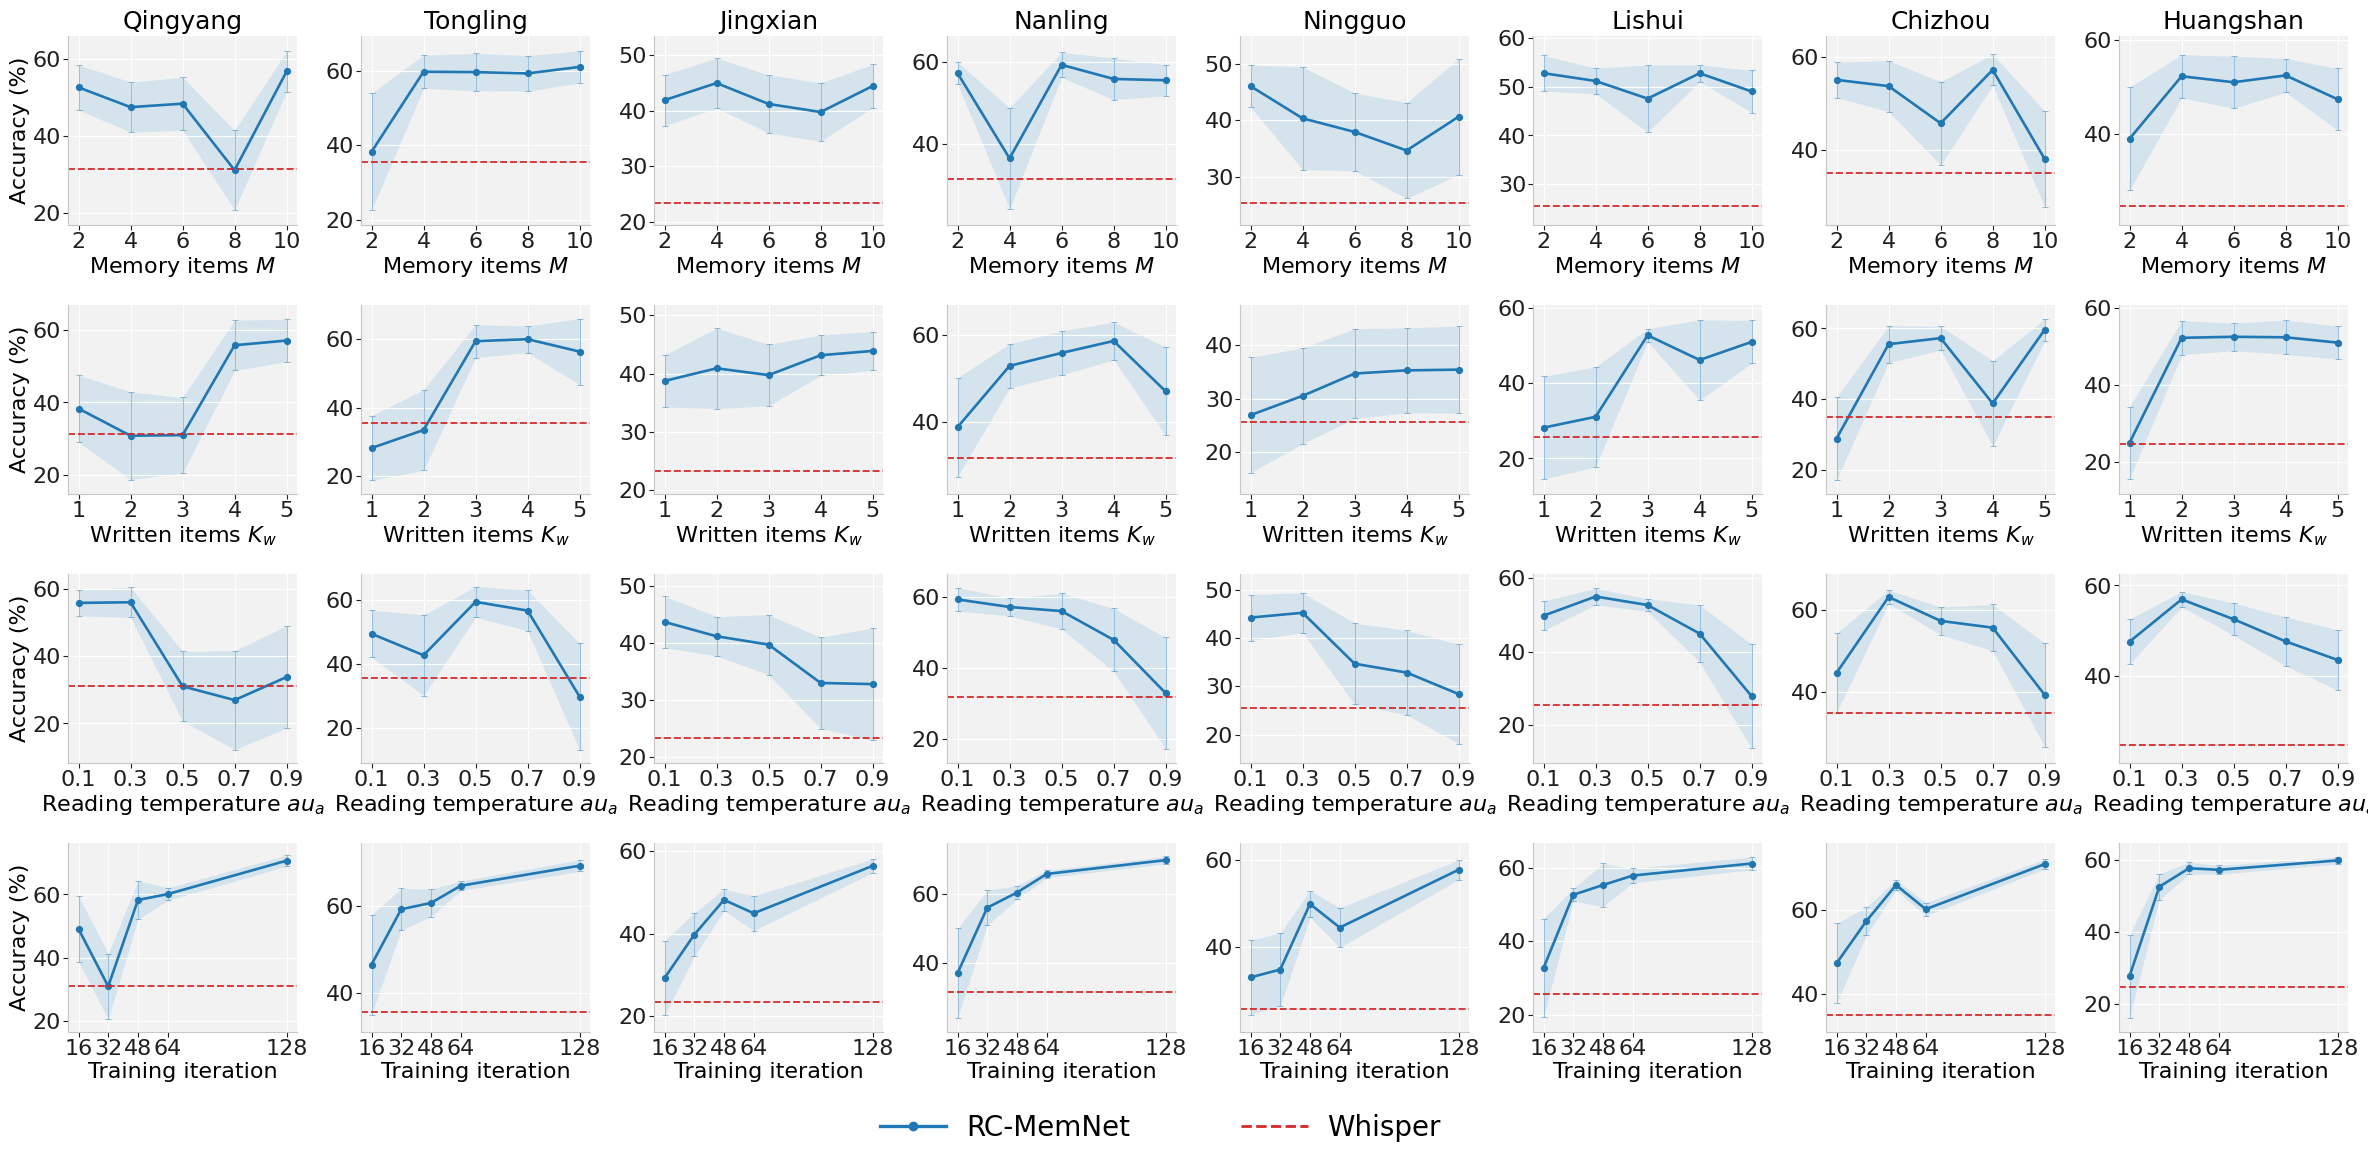

In [3]:
import csv
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import logging

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)


# =========================
# 1. Configuration
# =========================

SUMMARY_CSV = Path(
    "/home/ustc1958/lxy/graph/tone/complete_package0614/output/0614/"
    "hyperparam_sensitivity_8targets_k4_full_20260703_4sweeps/summary.csv"
)

OUTPUT_JPG = Path(
    "/home/ustc1958/lxy/graph/tone/complete_package0614/"
    "pc_dlcmnet_figures_hybrid/hyperparam_accuracy_4x8.jpg"
)

OUTPUT_PDF = Path(
    "/home/ustc1958/lxy/graph/tone/complete_package0614/"
    "pc_dlcmnet_figures_hybrid/hyperparam_accuracy_4x8.pdf"
)

BASELINE_TABLES = [
    Path(
        "/home/ustc1958/lxy/graph/tone/complete_package0614/output/0614/"
        "paper_ready_results/main_acc_table_global_support_s100.csv"
    ),
    Path(
        "/home/ustc1958/lxy/graph/tone/complete_package0614/output/0614/"
        "paper_ready_results/main_acc_4shot_add2_missing_baselines.csv"
    ),
]

AREA_ORDER = [
    "Qingyang", "Tongling", "Jingxian", "Nanling",
    "Ningguo", "Lishui", "Chizhou", "Huangshan"
]

SWEEPS = ["num_prompts", "lambda_global", "temperature", "episode_length"]

# 保留 summary.csv 中原来的 sweep 键，只修改论文图中显示的名称。
SWEEP_LABELS = {
    "num_prompts": r"Memory items $M$",
    "lambda_global": r"Written items $K_w$",
    "temperature": r"Reading temperature $	au_a$",
    "episode_length": "Training iteration",
}

# 只修改 x 轴刻度显示，不改变曲线数据、坐标位置和整体布局。
#
# num_prompts 的原始取值通常可直接作为 M 使用，因此保持原刻度。
# lambda_global 的四个原始取值按从小到大依次显示为 K_w=1,2,3,4。
# 若该 sweep 的点数不是 4，只需修改下面对应列表。
X_TICK_LABELS_BY_ORDER = {
    "num_prompts": None,
    # lambda_global 这一行现在仅借用原有 5 个实验点的位置，
    # 显示为 Written items K_w = 1, 2, ..., N。
    # 使用 "auto_index" 后会根据每个面板的实际点数自动生成，
    # 不再因点数变化报错。
    "lambda_global": "auto_index",
    "temperature": None,
    "episode_length": None,
}

BASELINE_METHOD = "WavLM"


# =========================
# 1.1 Figure size
# =========================

FIG_WIDTH = 24.0
FIG_HEIGHT = 12
DPI = 300

SHOW_FIG = True
SAVE_FIG = True


# =========================
# 1.2 Font settings
# =========================

FONT_FAMILY = "Times New Roman"

GLOBAL_FONT_SIZE = 18
AREA_TITLE_FONT_SIZE = 18
AXIS_LABEL_FONT_SIZE = 16
TICK_LABEL_FONT_SIZE = 16

# 底部图例字体大小
LEGEND_FONT_SIZE = 20

AREA_TITLE_PAD = 5
AXIS_LABEL_PAD = 2
TICK_PAD = 1.5


# =========================
# 1.3 Subplot spacing
# =========================

SUBPLOT_LEFT = 0.045
SUBPLOT_RIGHT = 0.995
SUBPLOT_TOP = 0.965

# 增大底部留白，给全局图例留空间
SUBPLOT_BOTTOM = 0.135

SUBPLOT_WSPACE = 0.28
SUBPLOT_HSPACE = 0.42


# =========================
# 1.4 Style settings
# =========================

AX_FACE_COLOR = "#f2f2f2"
FIG_FACE_COLOR = "white"

GCOPE_COLOR = "#1f77b4"
SHADE_COLOR = "#9ecae1"
BASELINE_COLOR = "#d62728"

GRID_COLOR = "white"
SPINE_COLOR = "#c7c7c7"
TICK_COLOR = "#1f1f1f"

GCOPE_LINE_WIDTH = 1.9
GCOPE_MARKER_SIZE = 4.2

ERROR_LINE_WIDTH = 0.75
ERROR_CAP_SIZE = 2.2
ERROR_CAP_THICK = 0.75
ERROR_ALPHA = 0.45

SHADE_ALPHA = 0.34

BASELINE_LINE_WIDTH = 1.35
BASELINE_ALPHA = 0.95
BASELINE_LINESTYLE = "--"

GRID_LINE_WIDTH = 0.8
GRID_ALPHA = 0.95

SPINE_LINE_WIDTH = 0.8


# =========================
# 1.5 Legend settings
# =========================

# 底部全局图例名称，在这里改即可
GLOBAL_LEGEND_CURVE_LABEL = "RC-MemNet"
GLOBAL_LEGEND_BASELINE_LABEL = "Whisper"

# 底部全局图例位置
GLOBAL_LEGEND_LOC = "lower center"
GLOBAL_LEGEND_BBOX = (0.5, 0.025)
GLOBAL_LEGEND_NCOL = 2

# 是否显示图例边框
LEGEND_FRAME_ON = False

# 图例背景透明度；frameon=False 时这个参数不会显示出来
LEGEND_FRAME_ALPHA = 0.8

# 图例内部文字和边框之间的距离
LEGEND_BORDER_PAD = 0.3

# 图例中线段示例的长度
LEGEND_HANDLE_LENGTH = 2.4

# 图例中线段示例和文字之间的距离
LEGEND_HANDLE_TEXT_PAD = 0.7

# 图例列间距
LEGEND_COLUMN_SPACING = 4.0


# =========================
# 1.6 Y-axis range settings
# =========================

Y_MARGIN = 4.0
MIN_Y_SPAN = 14.0

STD_VIS_SCALE = 2.0


# =========================
# 1.7 Global rcParams
# =========================

plt.rcParams.update({
    "font.family": FONT_FAMILY,
    "font.size": GLOBAL_FONT_SIZE,
    "axes.titlesize": AREA_TITLE_FONT_SIZE,
    "axes.labelsize": AXIS_LABEL_FONT_SIZE,
    "xtick.labelsize": TICK_LABEL_FONT_SIZE,
    "ytick.labelsize": TICK_LABEL_FONT_SIZE,
    "legend.fontsize": LEGEND_FONT_SIZE,
    "axes.linewidth": SPINE_LINE_WIDTH,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


# =========================
# 2. Helper functions
# =========================

def as_float(value):
    return float(str(value).strip())


def clean_row(row):
    return {str(k).lstrip("\ufeff"): v for k, v in row.items()}


def method_matches(name, target):
    clean_name = name.lower().replace("~", "").replace(" ", "").replace("-", "")
    clean_target = target.lower().replace("~", "").replace(" ", "").replace("-", "")
    return clean_name == clean_target


def load_summary_rows(summary_csv):
    rows = []

    with summary_csv.open("r", encoding="utf-8-sig", newline="") as f:
        reader = csv.DictReader(f)

        for raw_row in reader:
            row = clean_row(raw_row)

            # skipped 表示结果已存在而跳过重跑，也应计入画图
            if row.get("returncode") == "0" and row.get("status") in {"done", "skipped"}:
                rows.append(row)

    if not rows:
        raise RuntimeError(f"No valid rows found in {summary_csv}")

    return rows


def group_by_sweep_area(rows):
    grouped = {}

    for row in rows:
        key = (row["sweep"], row["area"])
        grouped.setdefault(key, []).append(row)

    for key in grouped:
        grouped[key].sort(key=lambda r: as_float(r["value"]))

    return grouped


def load_baselines(baseline_tables, method=BASELINE_METHOD):
    baselines = {}

    for path in baseline_tables:
        if not path.exists():
            continue

        with path.open("r", encoding="utf-8-sig", newline="") as f:
            reader = csv.DictReader(f)

            for raw_row in reader:
                row = clean_row(raw_row)

                if not method_matches(row.get("Method", ""), method):
                    continue

                for area in AREA_ORDER:
                    value = row.get(area, "")

                    if value:
                        baselines[area] = as_float(value) * 100.0

    return baselines


# =========================
# 3. Load data
# =========================

rows = load_summary_rows(SUMMARY_CSV)
grouped = group_by_sweep_area(rows)
baselines = load_baselines(BASELINE_TABLES, BASELINE_METHOD)

print(f"Loaded summary rows: {len(rows)}")
print(f"Loaded baselines: {len(baselines)} / {len(AREA_ORDER)}")


# =========================
# 4. Plot
# =========================

fig, axes = plt.subplots(
    nrows=len(SWEEPS),
    ncols=len(AREA_ORDER),
    figsize=(FIG_WIDTH, FIG_HEIGHT),
    sharey=False,
)

fig.patch.set_facecolor(FIG_FACE_COLOR)

for row_idx, sweep in enumerate(SWEEPS):
    for col_idx, area in enumerate(AREA_ORDER):
        ax = axes[row_idx][col_idx]

        data = grouped.get((sweep, area), [])

        x = [as_float(item["value"]) for item in data]
        y = [as_float(item["accuracy"]) * 100.0 for item in data]

        y_std = [
            as_float(item.get("accuracy_std", "0")) * 100.0 * STD_VIS_SCALE
            for item in data
        ]

        y_low = [max(0.0, mean - std) for mean, std in zip(y, y_std)]
        y_high = [min(100.0, mean + std) for mean, std in zip(y, y_std)]

        ax.set_facecolor(AX_FACE_COLOR)

        if x:
            ax.fill_between(
                x,
                y_low,
                y_high,
                color=SHADE_COLOR,
                alpha=SHADE_ALPHA,
                linewidth=0,
            )

            ax.errorbar(
                x,
                y,
                yerr=y_std,
                fmt="none",
                ecolor=GCOPE_COLOR,
                elinewidth=ERROR_LINE_WIDTH,
                capsize=ERROR_CAP_SIZE,
                capthick=ERROR_CAP_THICK,
                alpha=ERROR_ALPHA,
                zorder=2,
            )

            ax.plot(
                x,
                y,
                marker="o",
                linewidth=GCOPE_LINE_WIDTH,
                markersize=GCOPE_MARKER_SIZE,
                color=GCOPE_COLOR,
                label=GLOBAL_LEGEND_CURVE_LABEL,
            )

        if area in baselines:
            ax.axhline(
                baselines[area],
                color=BASELINE_COLOR,
                linestyle=BASELINE_LINESTYLE,
                linewidth=BASELINE_LINE_WIDTH,
                alpha=BASELINE_ALPHA,
                label=GLOBAL_LEGEND_BASELINE_LABEL,
            )

        y_candidates = y_low + y_high

        if area in baselines:
            y_candidates.append(baselines[area])

        if y_candidates:
            ymin = max(0.0, min(y_candidates) - Y_MARGIN)
            ymax = min(100.0, max(y_candidates) + Y_MARGIN)

            if ymax - ymin < MIN_Y_SPAN:
                mid = (ymax + ymin) / 2.0
                ymin = max(0.0, mid - MIN_Y_SPAN / 2.0)
                ymax = min(100.0, mid + MIN_Y_SPAN / 2.0)

            ax.set_ylim(ymin, ymax)

        ax.set_xticks(x)

        # 仅替换 x 轴刻度文字；曲线仍使用原始 x 坐标。
        custom_tick_labels = X_TICK_LABELS_BY_ORDER.get(sweep)

        if custom_tick_labels == "auto_index":
            # 仅修改显示文本，不改变原始 x 坐标和曲线形状。
            ax.set_xticklabels(
                [str(i) for i in range(1, len(x) + 1)]
            )

        elif custom_tick_labels is not None:
            if len(custom_tick_labels) != len(x):
                raise ValueError(
                    f"{sweep} has {len(x)} x values, but "
                    f"{len(custom_tick_labels)} custom tick labels were provided. "
                    "Please update X_TICK_LABELS_BY_ORDER."
                )
            ax.set_xticklabels(custom_tick_labels)

        ax.grid(
            True,
            axis="y",
            color=GRID_COLOR,
            linewidth=GRID_LINE_WIDTH,
            alpha=GRID_ALPHA,
        )
        ax.grid(
            True,
            axis="x",
            color=GRID_COLOR,
            linewidth=GRID_LINE_WIDTH,
            alpha=GRID_ALPHA,
        )

        ax.tick_params(
            axis="x",
            labelsize=TICK_LABEL_FONT_SIZE,
            pad=TICK_PAD,
            colors=TICK_COLOR,
        )
        ax.tick_params(
            axis="y",
            labelsize=TICK_LABEL_FONT_SIZE,
            pad=TICK_PAD,
            colors=TICK_COLOR,
        )

        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)

        ax.spines["left"].set_color(SPINE_COLOR)
        ax.spines["bottom"].set_color(SPINE_COLOR)

        ax.spines["left"].set_linewidth(SPINE_LINE_WIDTH)
        ax.spines["bottom"].set_linewidth(SPINE_LINE_WIDTH)

        # Column titles are shown only in the first row.
        if row_idx == 0:
            ax.set_title(
                area,
                fontsize=AREA_TITLE_FONT_SIZE,
                pad=AREA_TITLE_PAD,
            )
        else:
            ax.set_title("")

        # The y-axis title is shown only in the first column.
        if col_idx == 0:
            ax.set_ylabel(
                "Accuracy (%)",
                fontsize=AXIS_LABEL_FONT_SIZE,
                labelpad=AXIS_LABEL_PAD,
            )
        else:
            ax.set_ylabel("")

        ax.set_xlabel(
            SWEEP_LABELS[sweep],
            fontsize=AXIS_LABEL_FONT_SIZE,
            labelpad=AXIS_LABEL_PAD,
        )


# =========================
# 5. Global legend
# =========================

legend_handles = [
    Line2D(
        [0], [0],
        color=GCOPE_COLOR,
        marker="o",
        linewidth=2.4,
        markersize=6.0,
        label=GLOBAL_LEGEND_CURVE_LABEL,
    ),
    Line2D(
        [0], [0],
        color=BASELINE_COLOR,
        linestyle=BASELINE_LINESTYLE,
        linewidth=2.0,
        label=GLOBAL_LEGEND_BASELINE_LABEL,
    ),
]

fig.legend(
    handles=legend_handles,
    loc=GLOBAL_LEGEND_LOC,
    bbox_to_anchor=GLOBAL_LEGEND_BBOX,
    ncol=GLOBAL_LEGEND_NCOL,
    fontsize=LEGEND_FONT_SIZE,
    frameon=LEGEND_FRAME_ON,
    framealpha=LEGEND_FRAME_ALPHA,
    borderpad=LEGEND_BORDER_PAD,
    handlelength=LEGEND_HANDLE_LENGTH,
    handletextpad=LEGEND_HANDLE_TEXT_PAD,
    columnspacing=LEGEND_COLUMN_SPACING,
)


fig.subplots_adjust(
    left=SUBPLOT_LEFT,
    right=SUBPLOT_RIGHT,
    top=SUBPLOT_TOP,
    bottom=SUBPLOT_BOTTOM,
    wspace=SUBPLOT_WSPACE,
    hspace=SUBPLOT_HSPACE,
)


# =========================
# 6. Save and show
# =========================

OUTPUT_JPG.parent.mkdir(parents=True, exist_ok=True)
OUTPUT_PDF.parent.mkdir(parents=True, exist_ok=True)

if SAVE_FIG:
    fig.savefig(
        OUTPUT_JPG,
        dpi=DPI,
        bbox_inches="tight",
        pad_inches=0.04,
        pil_kwargs={"quality": 95},
    )
    fig.savefig(
        OUTPUT_PDF,
        bbox_inches="tight",
        pad_inches=0.04,
    )
    print(f"Saved JPG to: {OUTPUT_JPG}")
    print(f"Saved PDF to: {OUTPUT_PDF}")

if SHOW_FIG:
    plt.show()

plt.close(fig)